# 01 — In-depth Spectral & Molecular EDA
### Enveda CASMI 2026 — Molecule Identification From Tandem Mass Spectra

This notebook starts **directly from the competition tables** in `../data/` and focuses only on the scientific/modeling questions that matter for this task.

There is **no input-directory crawling, file discovery, generic file profiling, or file-oriented EDA**.

The analysis covers the full set of available variables:

- **Structure / target:** `normalized_smiles`, `inchikey`, `inchikey14`, `molecular_formula`
- **Acquisition context:** `ingest_lib`, `ionization_mode`, `instrument_type`, `adduct`, `adduct_orig`
- **Precursor information:** `precursor_mz`, `precursor_error_ppm`
- **MS/MS spectrum:** `ms2_mzs`, `ms2_normalized_intensities`, `num_peaks`, `base_peak_intensity`
- **Collision energy:** `collision_energy_ev`, `collision_energy_orig`, `collision_energy_orig_units`
- **Test identifiers:** `molecule_id`, `spectrum_id`

The goals are to understand spectral behavior, chemical diversity, acquisition effects, train/test shift, duplication/leakage risk, candidate-space difficulty, and the validation strategy that should be used downstream.

> **Target:** ranked list of candidate molecular structures / SMILES.  
> **Validation principle:** spectra from the same molecular connectivity must never leak across train/validation folds.


## 1. Imports and reproducibility


In [1]:
import sys, os, re, json, math, time, warnings, random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

from scipy import stats as sp_stats
from scipy.spatial.distance import cosine as scipy_cosine

from sklearn.model_selection import GroupKFold

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

try:
    import rdkit
    from rdkit import Chem, RDLogger
    from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors, DataStructs, Draw
    from rdkit.Chem.Scaffolds import MurckoScaffold
    RDLogger.DisableLog("rdApp.*")
    RDKIT_AVAILABLE = True
    print("RDKit version:", rdkit.__version__)
except ImportError as e:
    RDKIT_AVAILABLE = False
    print("RDKit not available:", e)

import sklearn, scipy
import matplotlib as mpl

print("Python       :", sys.version.split()[0])
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("SciPy        :", scipy.__version__)
print("scikit-learn :", sklearn.__version__)
print("Matplotlib   :", mpl.__version__)


RDKit version: 2026.03.6
Python       : 3.10.20
NumPy        : 1.26.4
Pandas       : 2.3.3
SciPy        : 1.15.3
scikit-learn : 1.5.2
Matplotlib   : 3.10.9


## 2. Direct data load

The project layout is fixed:

```text
project/
├── data/
│   ├── train.parquet
│   ├── test.parquet
│   └── sample_submission.csv
└── notebooks/
    └── 01_....ipynb
```

We load those three files directly and start the domain EDA immediately.


In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

train_df = pd.read_parquet(DATA_DIR / "train.parquet")
test_df = pd.read_parquet(DATA_DIR / "test.parquet")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

# train does not necessarily provide a spectrum identifier; create a stable notebook-local one.
if "spectrum_id" not in train_df.columns:
    train_df["spectrum_id"] = "train_" + train_df.index.astype(str)

print(f"Train             : {train_df.shape}")
print(f"Test              : {test_df.shape}")
print(f"Sample submission : {sample_submission.shape}")

print("\nTRAIN columns:")
print(train_df.columns.tolist())

print("\nTEST columns:")
print(test_df.columns.tolist())

display(train_df.head(3))
display(test_df.head(3))


Train             : (2539608, 19)
Test              : (1213, 12)
Sample submission : (400, 2)

TRAIN columns:
['ingest_lib', 'normalized_smiles', 'inchikey', 'inchikey14', 'molecular_formula', 'ionization_mode', 'instrument_type', 'adduct', 'adduct_orig', 'precursor_mz', 'precursor_error_ppm', 'ms2_mzs', 'ms2_normalized_intensities', 'num_peaks', 'base_peak_intensity', 'collision_energy_ev', 'collision_energy_orig', 'collision_energy_orig_units', 'spectrum_id']

TEST columns:
['molecule_id', 'spectrum_id', 'ms2_mzs', 'ms2_normalized_intensities', 'base_peak_intensity', 'adduct', 'ionization_mode', 'instrument_type', 'precursor_mz', 'collision_energy_orig', 'collision_energy_ev', 'collision_energy_orig_units']


,ingest_lib,normalized_smiles,inchikey,inchikey14,molecular_formula,ionization_mode,instrument_type,adduct,adduct_orig,precursor_mz,precursor_error_ppm,ms2_mzs,ms2_normalized_intensities,num_peaks,base_peak_intensity,collision_energy_ev,collision_energy_orig,collision_energy_orig_units,spectrum_id
0,drug_plus,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,AAALVYBICLMAMA-UHFFFAOYSA-N,AAALVYBICLMAMA,C20H15N3O2,positive,None,[M+H]+,[M+H]+,330.1237,1.6714,"[92.0495, 93.0573, 94.0607, 116.107, 123.1168, 124.1203, 133.0761, 142.0777, 142.1226, 166.0655, 167.0734, 168.0808, 169.0838, 169.0886, 170.092, 176.0457, 181.076, 184.0758, 185.0709, 188.0452, 1...","[0.0171037726229424, 0.328091214993177, 0.0107218611515595, 0.0260808387356118, 0.00689810236918518, 0.000731897656782594, 0.00296068467031701, 0.00198119486676545, 0.000714763563882375, 0.0019352...",52,NaN,None,None,unknown,train_0
1,drug_plus,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,AAKJLRGGTJKAMG-UHFFFAOYSA-N,AAKJLRGGTJKAMG,C22H23N3O4,positive,None,[M+K]+,[M+K]+,432.1320,1.3022,"[82.1451, 89.0599, 158.9638, 248.0836, 250.0985, 251.1026, 276.0778, 277.0857, 278.0937, 280.0999, 290.0934, 291.1, 292.1096, 293.1147, 298.0576, 303.1002, 304.1097, 306.1138, 318.1266, 325.082, 3...","[0.00144055962319783, 0.959302375462881, 0.5, 0.000515701917270155, 0.0376652132213415, 0.0024956215528578, 0.0114570281771694, 0.0423268471416211, 1.0, 0.00545938583506271, 0.0117478031822994, 0....",28,NaN,None,None,unknown,train_1
2,drug_plus,CC1(C)CCC(C)(C)c2cc(C(O)C(O)=Nc3ccc(C(=O)O)cc3F)ccc21,AANFHDFOMFRLLR-UHFFFAOYSA-N,AANFHDFOMFRLLR,C23H26FNO4,positive,None,[M+Na]+,[M+Na]+,422.1738,1.3164,"[91.0539, 111.117, 131.0856, 150.035, 171.0803, 187.148, 188.1531, 194.0247, 194.034, 194.034, 268.1123, 268.1123, 270.0933, 272.072, 273.0753, 282.1288, 282.1288, 284.0716, 284.0716, 284.1082, 28...","[0.00262159533923045, 0.0184752871374318, 0.00470403847262502, 0.00290264206747667, 0.00415629437299262, 0.00416269460783017, 0.00266644087369943, 0.0508698097578002, 0.00431464019455703, 0.004314...",41,NaN,None,None,unknown,train_2


,molecule_id,spectrum_id,ms2_mzs,ms2_normalized_intensities,base_peak_intensity,adduct,ionization_mode,instrument_type,precursor_mz,collision_energy_orig,collision_energy_ev,collision_energy_orig_units
0,m_005e53,s_4d19d522,"[67.0414, 73.0074, 74.0142, 74.0174, 75.0238, 76.0313, 77.0357, 77.0398, 78.0348, 78.0469, 79.0411, 80.0501, 81.051, 81.0539, 82.0655, 86.0166, 89.036, 89.0405, 90.0469, 91.0551, 91.058, 92.0504, ...","[0.0016501163269310492, 0.0004909040749095276, 0.002606475655436237, 0.00012318704809900993, 0.003683440267559318, 0.01094483728244946, 0.00039832937708661893, 0.001985008062481651, 0.012448530680...","2,711,324.0000",[M+H]+,positive,timsTOF,375.0709,"20,40,60","[20.0, 40.0, 60.0]",eV
1,m_005e53,s_5b6e28ff,"[67.0414, 73.0074, 74.0174, 75.0236, 76.0311, 78.0337, 79.0411, 80.0502, 81.051, 82.0655, 90.0472, 92.0503, 92.0595, 93.0527, 93.0575, 94.0654, 101.0395, 102.0474, 103.05, 104.0494, 106.0307, 108....","[0.0029581573469943693, 0.0008800418929033316, 0.00022083695885027253, 0.0002426561793354791, 0.006321623244213939, 0.0006003591575929564, 0.0018176071852676623, 0.04304006537831884, 0.00137791683...","1,512,428.0000",[M+H]+,positive,timsTOF,375.0709,40,[40.0],eV
2,m_005e53,s_6e514292,"[74.0142, 75.0238, 76.0313, 77.0357, 77.0398, 78.0349, 78.0469, 80.05, 81.0539, 86.0166, 89.036, 89.0405, 90.0469, 91.0551, 91.058, 92.046, 92.0505, 93.0529, 93.0575, 94.0664, 96.0452, 101.0394, 1...","[0.0071407135863519105, 0.009720343101840298, 0.02032380261438833, 0.0010912651299363329, 0.005438137897516058, 0.03318658511817492, 0.0029827913551593093, 0.07162740975085811, 0.00301815642881465...","989,677.0000",[M+H]+,positive,timsTOF,375.0709,60,[60.0],eV


## 3. Competition-aware variable map


In [3]:
DATA_MAP = {
    "molecule_id_col": "inchikey14",              # train grouping / connectivity key
    "test_molecule_id_col": "molecule_id",        # test target identifier
    "spectrum_id_col": "spectrum_id",
    "smiles_col": "normalized_smiles",
    "formula_col": "molecular_formula",

    "library_col": "ingest_lib",
    "ion_mode_col": "ionization_mode",
    "instrument_col": "instrument_type",
    "adduct_col": "adduct",
    "adduct_original_col": "adduct_orig",

    "precursor_mz_col": "precursor_mz",
    "precursor_error_ppm_col": "precursor_error_ppm",

    "peaks_col": "ms2_mzs",
    "peaks_intensity_col": "ms2_normalized_intensities",
    "num_peaks_col": "num_peaks",
    "base_peak_intensity_col": "base_peak_intensity",

    "collision_energy_col": "collision_energy_ev",
    "collision_energy_original_col": "collision_energy_orig",
    "collision_energy_units_col": "collision_energy_orig_units",
}

mol_col = DATA_MAP["molecule_id_col"]
test_mol_col = DATA_MAP["test_molecule_id_col"]
spec_col = DATA_MAP["spectrum_id_col"]
smiles_col = DATA_MAP["smiles_col"]
formula_col = DATA_MAP["formula_col"]

library_col = DATA_MAP["library_col"]
ion_col = DATA_MAP["ion_mode_col"]
inst_col = DATA_MAP["instrument_col"]
adduct_col = DATA_MAP["adduct_col"]
adduct_orig_col = DATA_MAP["adduct_original_col"]

mz_col = DATA_MAP["precursor_mz_col"]
ppm_col = DATA_MAP["precursor_error_ppm_col"]
peaks_col = DATA_MAP["peaks_col"]
peaks_intensity_col = DATA_MAP["peaks_intensity_col"]
num_peaks_col = DATA_MAP["num_peaks_col"]
base_peak_intensity_col = DATA_MAP["base_peak_intensity_col"]

ce_col = DATA_MAP["collision_energy_col"]
ce_orig_col = DATA_MAP["collision_energy_original_col"]
ce_units_col = DATA_MAP["collision_energy_units_col"]

SEMANTIC_GROUPS = {
    "structure_target": [
        "normalized_smiles", "inchikey", "inchikey14", "molecular_formula"
    ],
    "acquisition_metadata": [
        "ingest_lib", "ionization_mode", "instrument_type", "adduct", "adduct_orig"
    ],
    "precursor": [
        "precursor_mz", "precursor_error_ppm"
    ],
    "spectrum_arrays": [
        "ms2_mzs", "ms2_normalized_intensities"
    ],
    "spectrum_summary": [
        "num_peaks", "base_peak_intensity"
    ],
    "collision_energy": [
        "collision_energy_ev", "collision_energy_orig", "collision_energy_orig_units"
    ],
    "identifiers": [
        "spectrum_id", "molecule_id"
    ],
}

print("Observation unit : spectrum")
print("Training group   : molecular connectivity (inchikey14)")
print("Target           : molecular structure / normalized SMILES")
print("\nSemantic groups:")
for k, cols in SEMANTIC_GROUPS.items():
    present_tr = [c for c in cols if c in train_df.columns]
    present_te = [c for c in cols if c in test_df.columns]
    print(f"- {k:22s} train={present_tr} | test={present_te}")


Observation unit : spectrum
Training group   : molecular connectivity (inchikey14)
Target           : molecular structure / normalized SMILES

Semantic groups:
- structure_target       train=['normalized_smiles', 'inchikey', 'inchikey14', 'molecular_formula'] | test=[]
- acquisition_metadata   train=['ingest_lib', 'ionization_mode', 'instrument_type', 'adduct', 'adduct_orig'] | test=['ionization_mode', 'instrument_type', 'adduct']
- precursor              train=['precursor_mz', 'precursor_error_ppm'] | test=['precursor_mz']
- spectrum_arrays        train=['ms2_mzs', 'ms2_normalized_intensities'] | test=['ms2_mzs', 'ms2_normalized_intensities']
- spectrum_summary       train=['num_peaks', 'base_peak_intensity'] | test=['base_peak_intensity']
- collision_energy       train=['collision_energy_ev', 'collision_energy_orig', 'collision_energy_orig_units'] | test=['collision_energy_ev', 'collision_energy_orig', 'collision_energy_orig_units']
- identifiers            train=['spectrum_id'] | te

## 4. Full raw-variable EDA

This section deliberately touches **every available raw variable** before moving to derived chemistry/spectral analyses.

The audit is domain-aware:
- scalar columns get missingness/cardinality/distribution summaries;
- list-valued spectral columns get length and content summaries rather than expensive generic `nunique`;
- train/test comparisons use only variables genuinely observable in both datasets.


In [4]:
# ---------- 4.1 Compact inventory of every raw column ----------

def _is_array_like_value(x):
    return isinstance(x, (list, tuple, np.ndarray))

def _safe_missing_pct(s):
    # Series.isna() is safe for object columns even when cells contain ndarrays.
    return float(s.isna().mean() * 100)

def _first_non_null(s):
    for x in s:
        if x is not None:
            try:
                if not (isinstance(x, float) and np.isnan(x)):
                    return x
            except Exception:
                return x
    return None

def column_profile(df, name):
    rows = []
    for col in df.columns:
        s = df[col]
        ex = _first_non_null(s)
        is_array = _is_array_like_value(ex)

        if is_array:
            lengths = s.map(lambda x: len(x) if _is_array_like_value(x) else np.nan)
            rows.append({
                "dataset": name,
                "column": col,
                "dtype": str(s.dtype),
                "kind": "array/list",
                "missing_%": round(_safe_missing_pct(s), 2),
                "n_unique": np.nan,
                "array_len_median": lengths.median(),
                "array_len_p95": lengths.quantile(.95),
                "example": f"{type(ex).__name__}[{len(ex)}]" if ex is not None else None,
            })
        else:
            try:
                n_unique = s.nunique(dropna=True)
            except Exception:
                n_unique = np.nan
            rows.append({
                "dataset": name,
                "column": col,
                "dtype": str(s.dtype),
                "kind": "scalar/text",
                "missing_%": round(_safe_missing_pct(s), 2),
                "n_unique": n_unique,
                "array_len_median": np.nan,
                "array_len_p95": np.nan,
                "example": ex,
            })
    return pd.DataFrame(rows)

raw_inventory = pd.concat(
    [column_profile(train_df, "train"), column_profile(test_df, "test")],
    ignore_index=True
)

display(raw_inventory)


,dataset,column,dtype,kind,missing_%,n_unique,array_len_median,array_len_p95,example
0,train,ingest_lib,object,scalar/text,0.0000,11.0000,NaN,NaN,drug_plus
1,train,normalized_smiles,object,scalar/text,0.0000,"277,566.0000",NaN,NaN,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21
2,train,inchikey,object,scalar/text,0.0000,"275,950.0000",NaN,NaN,AAALVYBICLMAMA-UHFFFAOYSA-N
3,train,inchikey14,object,scalar/text,0.0000,"275,810.0000",NaN,NaN,AAALVYBICLMAMA
4,train,molecular_formula,object,scalar/text,0.0000,"51,291.0000",NaN,NaN,C20H15N3O2
5,train,ionization_mode,object,scalar/text,0.0000,2.0000,NaN,NaN,positive
6,train,instrument_type,object,scalar/text,1.3000,82.0000,NaN,NaN,nan
7,train,adduct,object,scalar/text,0.0000,121.0000,NaN,NaN,[M+H]+
8,train,adduct_orig,object,scalar/text,0.0000,123.0000,NaN,NaN,[M+H]+
9,train,precursor_mz,float64,scalar/text,0.0000,"356,549.0000",NaN,NaN,330.1237


TRAIN STRUCTURAL TARGET / IDENTIFIER CARDINALITIES
normalized_smiles    non-null=2,539,608 | unique=277,566 | duplicated rows=2,521,895
inchikey             non-null=2,539,608 | unique=275,950 | duplicated rows=2,522,550
inchikey14           non-null=2,539,608 | unique=275,810 | duplicated rows=2,522,575
molecular_formula    non-null=2,539,608 | unique=51,291 | duplicated rows=2,535,707

Spectra per molecular connectivity:


,spectra_per_molecule
count,"275,810.0000"
mean,9.2078
std,21.0696
min,1.0000
50%,6.0000
75%,9.0000
90%,14.0000
95%,21.0000
99%,79.0000
max,"1,468.0000"


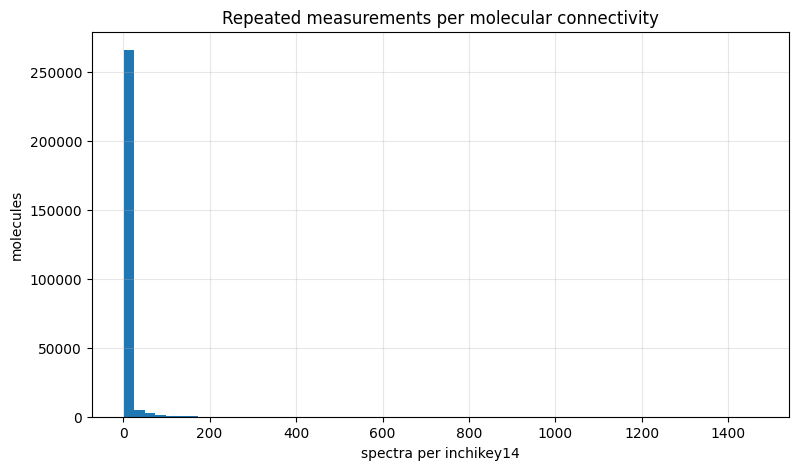


Most frequent molecular formulas:


,spectra
molecular_formula,
C19H24N4O2,3203
C15H10O5,3027
C21H20O11,3004
C18H24N4O2,2873
C17H22N4O2,2756
C18H22N4O2,2738
C19H23N3O3,2706
C27H30O15,2697
C21H20O10,2688


In [5]:
# ---------- 4.2 Structural/target identifiers ----------

target_cols = [c for c in ["normalized_smiles", "inchikey", "inchikey14", "molecular_formula"] if c in train_df.columns]

print("TRAIN STRUCTURAL TARGET / IDENTIFIER CARDINALITIES")
for c in target_cols:
    print(
        f"{c:20s} non-null={train_df[c].notna().sum():,} | "
        f"unique={train_df[c].nunique(dropna=True):,} | "
        f"duplicated rows={train_df[c].duplicated(keep=False).sum():,}"
    )

if mol_col in train_df.columns:
    spectra_per_molecule_raw = train_df.groupby(mol_col, sort=False).size()

    print("\nSpectra per molecular connectivity:")
    display(
        spectra_per_molecule_raw.describe(
            percentiles=[.5, .75, .90, .95, .99]
        ).to_frame("spectra_per_molecule")
    )

    fig, ax = plt.subplots()
    ax.hist(
        spectra_per_molecule_raw.values,
        bins=min(60, max(10, spectra_per_molecule_raw.nunique()))
    )
    ax.set_xlabel("spectra per inchikey14")
    ax.set_ylabel("molecules")
    ax.set_title("Repeated measurements per molecular connectivity")
    plt.show()

if formula_col in train_df.columns:
    formula_counts = train_df[formula_col].value_counts(dropna=False)
    print("\nMost frequent molecular formulas:")
    display(formula_counts.head(20).to_frame("spectra"))



ingest_lib
train: missing=0.00% | unique=11


,train_count
ingest_lib,
enveda-180,1153785
pluskal_ms2,527581
riken,347171
gnps,220849
massbank,101727
mona,92416
spectraverse,50933
msdial,40765
drug_plus,2545



ionization_mode
train: missing=0.00% | unique=2


,train_count
ionization_mode,
positive,1899640
negative,639968


test : missing=0.00% | unique=2


,train_pct,test_pct,abs_diff_pctpt
ionization_mode,,,
positive,74.8005,81.3685,6.5680
negative,25.1995,18.6315,6.5680


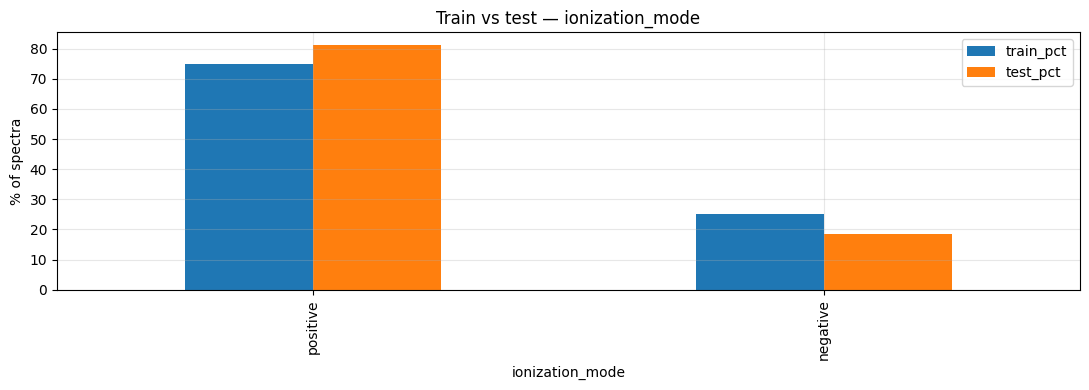


instrument_type
train: missing=1.30% | unique=82


,train_count
instrument_type,
timsTOF,1154969
Orbitrap,745562
QTOF,125936
LC-ESI-QTOF,104482
ESI-QFT,77342
LC-ESI-QFT,55024
LC-ESI-ITFT,45109
qTof,33777
None,33053


test : missing=0.00% | unique=1


,train_pct,test_pct,abs_diff_pctpt
instrument_type,,,
timsTOF,45.4782,100.0000,54.5218
Orbitrap,29.3574,0.0000,29.3574
QTOF,4.9589,0.0000,4.9589
LC-ESI-QTOF,4.1141,0.0000,4.1141
ESI-QFT,3.0454,0.0000,3.0454
LC-ESI-QFT,2.1666,0.0000,2.1666
LC-ESI-ITFT,1.7762,0.0000,1.7762
qTof,1.3300,0.0000,1.3300
None,1.3015,0.0000,1.3015



adduct
train: missing=0.00% | unique=121


...

,train_count
adduct_orig,
[M+H]+,1324585
[M-H]-,465688
[2M+Na]+,190033
[M+Na]+,178092
[2M+H]+,92041
[2M-H]-,56172
[M+H4N]+,53452
[M+CH2O2]-,52460
[M+CHO2]-,30728



collision_energy_orig_units
train: missing=0.00% | unique=4


,train_count
collision_energy_orig_units,
eV,1368908
NCE,789066
unknown,325078
V,56556


test : missing=0.00% | unique=1


,train_pct,test_pct,abs_diff_pctpt
collision_energy_orig_units,,,
eV,53.9023,100.0000,46.0977
NCE,31.0704,0.0000,31.0704
unknown,12.8003,0.0000,12.8003
V,2.2270,0.0000,2.2270


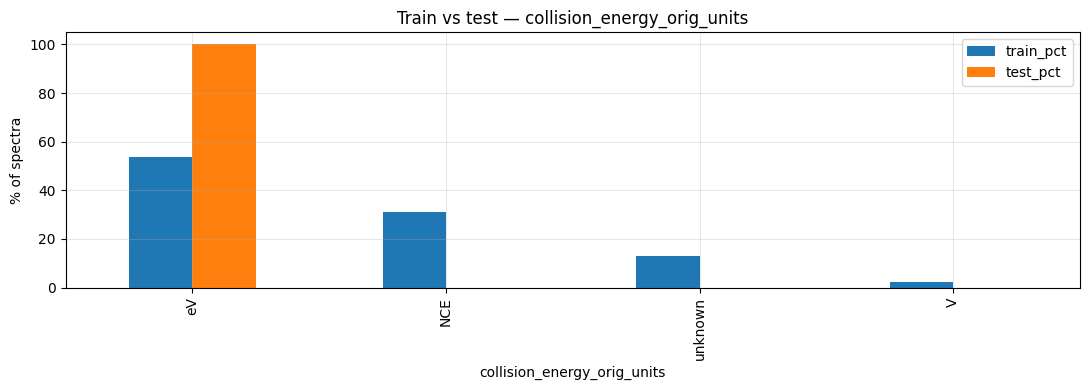


collision_energy_orig
train: missing=12.62% | unique=3,309


,train_count
collision_energy_orig,
None,320464
40,295237
60,272246
"20,40,60",240127
20,228105
-40,83279
60.0,74749
20.0,72995
-60,70248


test : missing=0.00% | unique=8


,train_pct,test_pct,abs_diff_pctpt
collision_energy_orig,,,
None,12.6186,0.0000,12.6186
40,11.6253,23.1657,11.5404
60,10.7200,23.8252,13.1052
"20,40,60",9.4553,21.1871,11.7319
20,8.9819,13.1904,4.2085
-40,3.2792,6.6777,3.3985
60.0,2.9433,0.0000,2.9433
20.0,2.8743,0.0000,2.8743
-60,2.7661,6.1006,3.3345


In [6]:
# ---------- 4.3 Categorical acquisition variables: ALL of them ----------

categorical_cols = [
    c for c in [
        "ingest_lib",
        "ionization_mode",
        "instrument_type",
        "adduct",
        "adduct_orig",
        "collision_energy_orig_units",
        "collision_energy_orig",
    ]
    if c in train_df.columns
]

for col in categorical_cols:
    print("\n" + "=" * 90)
    print(col)
    print("=" * 90)

    tr = train_df[col]
    print(
        f"train: missing={tr.isna().mean()*100:.2f}% | "
        f"unique={tr.nunique(dropna=True):,}"
    )
    display(tr.value_counts(dropna=False).head(20).to_frame("train_count"))

    if col in test_df.columns:
        te = test_df[col]
        print(
            f"test : missing={te.isna().mean()*100:.2f}% | "
            f"unique={te.nunique(dropna=True):,}"
        )

        tr_p = tr.value_counts(normalize=True, dropna=False)
        te_p = te.value_counts(normalize=True, dropna=False)
        cats = tr_p.index.union(te_p.index)

        comparison = pd.DataFrame({
            "train_pct": 100 * tr_p.reindex(cats, fill_value=0),
            "test_pct": 100 * te_p.reindex(cats, fill_value=0),
        })
        comparison["abs_diff_pctpt"] = (
            comparison["train_pct"] - comparison["test_pct"]
        ).abs()

        display(comparison.sort_values("train_pct", ascending=False).head(20))

        # Plot only manageable-cardinality categorical variables.
        if len(cats) <= 25:
            comparison.sort_values("train_pct", ascending=False)[["train_pct", "test_pct"]].plot(
                kind="bar", figsize=(11, 4)
            )
            plt.ylabel("% of spectra")
            plt.title(f"Train vs test — {col}")
            plt.tight_layout()
            plt.show()



precursor_mz
TRAIN


,precursor_mz
count,"2,539,608.0000"
mean,419.7696
std,"1,535.9865"
min,2.0000
1%,137.0710
5%,204.0655
25%,308.1410
50%,350.1088
75%,489.2142
95%,775.4660


TEST


,precursor_mz
count,"1,213.0000"
mean,327.9089
std,38.0894
min,245.0931
1%,250.1444
5%,269.7005
25%,300.1384
50%,329.1978
75%,347.1611
95%,395.1278


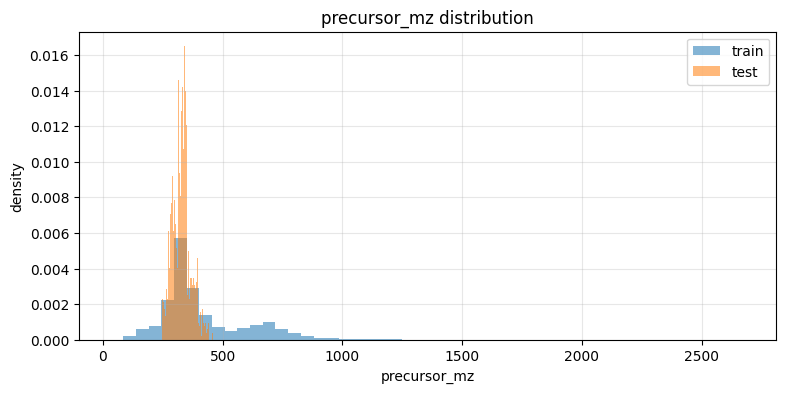


precursor_error_ppm
TRAIN


,precursor_error_ppm
count,"2,535,322.0000"
mean,"1,845.7265"
std,"511,752.5119"
min,-21.0615
1%,0.0300
5%,0.1545
25%,0.7755
50%,1.5121
75%,2.3453
95%,17.1815


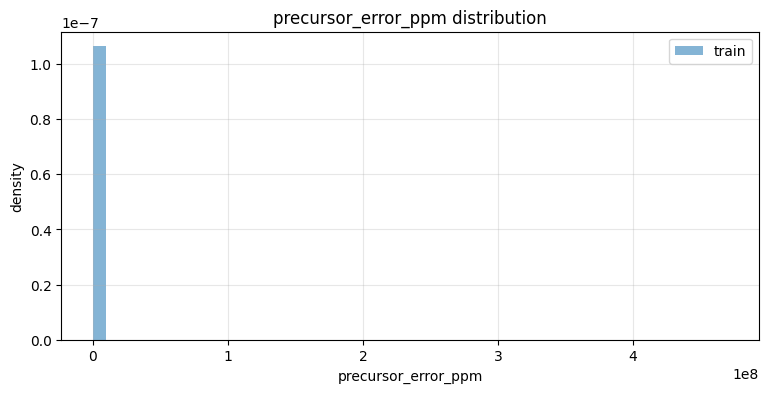


num_peaks
TRAIN


,num_peaks
count,"2,539,608.0000"
mean,158.2158
std,516.8801
min,1.0000
1%,1.0000
5%,3.0000
25%,14.0000
50%,42.0000
75%,164.0000
95%,628.0000


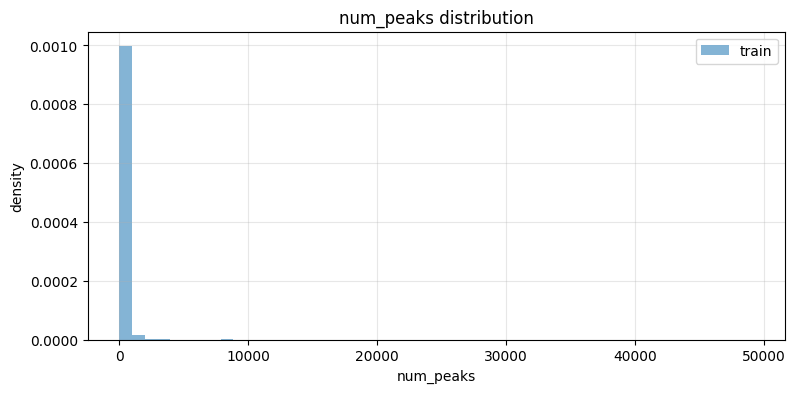


base_peak_intensity
TRAIN


,base_peak_intensity
count,"1,376,470.0000"
mean,"5,392,101.3915"
std,"52,954,461.1928"
min,1.0000
1%,100.0000
5%,100.0000
25%,"19,204.0000"
50%,"175,692.8125"
75%,"1,250,839.1250"
95%,"16,747,232.5500"


TEST


,base_peak_intensity
count,"1,213.0000"
mean,"3,509,204.6579"
std,"8,547,498.7174"
min,"1,018.0000"
1%,"1,476.9600"
5%,"4,458.6000"
25%,"86,896.0000"
50%,"474,227.0000"
75%,"2,768,804.0000"
95%,"17,594,104.4000"


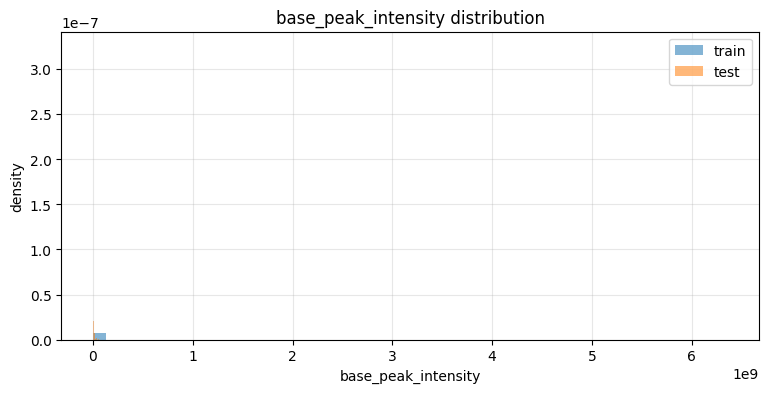


Spearman correlation — raw scalar numeric variables (train):


,precursor_mz,precursor_error_ppm,num_peaks,base_peak_intensity
precursor_mz,1.0000,-0.2476,-0.0802,-0.2484
precursor_error_ppm,-0.2476,1.0000,-0.4065,-0.2228
num_peaks,-0.0802,-0.4065,1.0000,0.5478
base_peak_intensity,-0.2484,-0.2228,0.5478,1.0000


In [7]:
# ---------- 4.4 Scalar numeric variables: ALL of them ----------

numeric_raw_cols = [
    c for c in [
        "precursor_mz",
        "precursor_error_ppm",
        "num_peaks",
        "base_peak_intensity",
    ]
    if c in train_df.columns
]

for col in numeric_raw_cols:
    print("\n" + "=" * 90)
    print(col)
    print("=" * 90)

    tr = pd.to_numeric(train_df[col], errors="coerce")
    print("TRAIN")
    display(
        tr.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]).to_frame(col)
    )

    if col in test_df.columns:
        te = pd.to_numeric(test_df[col], errors="coerce")
        print("TEST")
        display(
            te.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]).to_frame(col)
        )
    else:
        te = None

    fig, ax = plt.subplots(figsize=(9, 4))
    tr_plot = tr.dropna()
    if len(tr_plot) > 200_000:
        tr_plot = tr_plot.sample(200_000, random_state=SEED)
    ax.hist(tr_plot, bins=50, density=True, alpha=.55, label="train")

    if te is not None:
        te_plot = te.dropna()
        if len(te_plot) > 200_000:
            te_plot = te_plot.sample(200_000, random_state=SEED)
        ax.hist(te_plot, bins=50, density=True, alpha=.55, label="test")

    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    ax.legend()
    plt.show()

if len(numeric_raw_cols) >= 2:
    print("\nSpearman correlation — raw scalar numeric variables (train):")
    display(train_df[numeric_raw_cols].corr(method="spearman"))


TRAIN collision-energy derived summaries:


,ce_n_steps,ce_min,ce_mean,ce_max,ce_std,ce_range
count,"2,539,608.0000","2,202,165.0000","2,202,165.0000","2,202,165.0000","2,202,165.0000","2,202,165.0000"
mean,1.2890,32.7569,36.6937,40.9382,3.3419,8.1812
std,1.0008,20.4930,19.1268,20.8000,6.4592,15.7599
min,0.0000,0.0000,0.6000,0.6000,0.0000,0.0000
5%,0.0000,10.0000,10.0000,10.0000,0.0000,0.0000
25%,1.0000,20.0000,20.0000,20.0000,0.0000,0.0000
50%,1.0000,22.5000,40.0000,40.0000,0.0000,0.0000
75%,1.0000,40.0000,40.0000,60.0000,0.0000,0.0000
95%,3.0000,60.0000,60.0000,60.0000,16.3299,40.0000
99%,4.0000,93.7000,94.0000,99.3000,17.4918,41.5000


Missing/empty CE: 13.29%


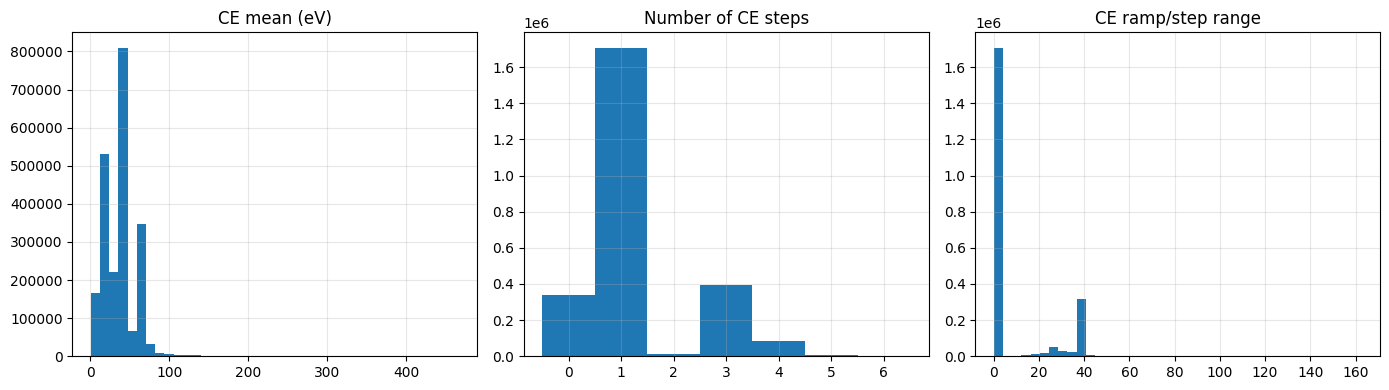


Distinct collision-energy settings per molecule:


,n_distinct_ce_settings
count,"275,810.0000"
mean,4.5847
std,4.2971
min,1.0000
50%,4.0000
75%,4.0000
90%,9.0000
95%,13.0000
99%,23.0000
max,76.0000


Molecules with >1 CE setting: 234,932/275,810 (85.18%)


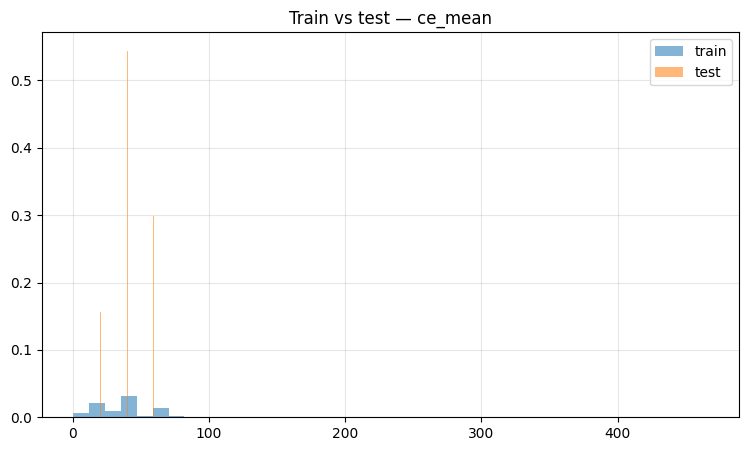

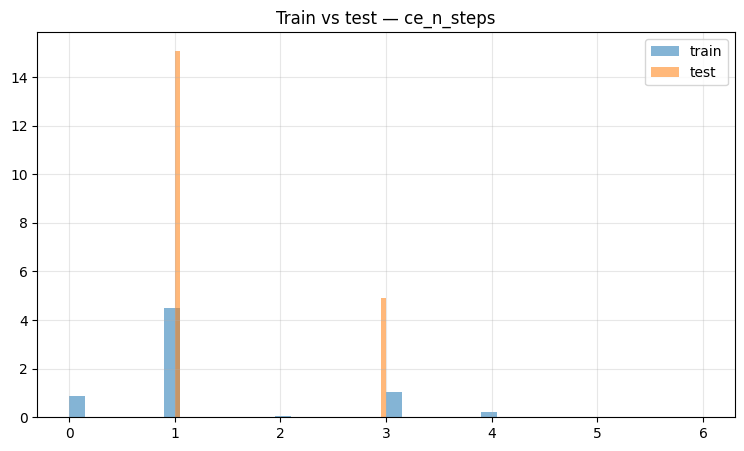

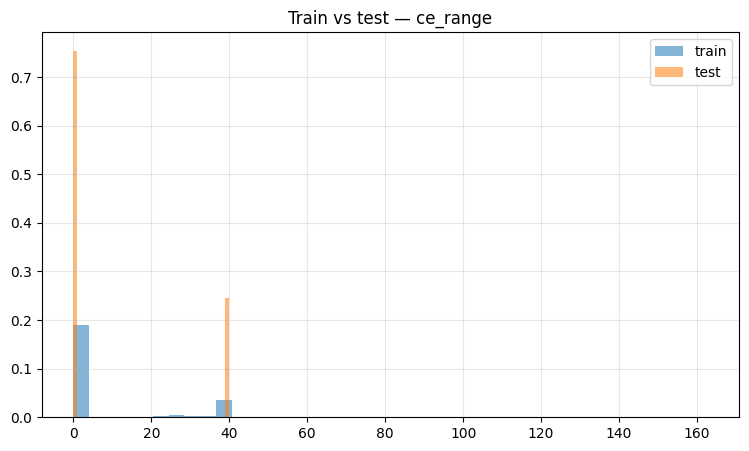

In [8]:
# ---------- 4.5 Collision energy: list-valued field, robust and FAST ----------

_FLOAT_RE = re.compile(r"[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?")

def to_float_array(x):
    if x is None:
        return np.array([], dtype=float)

    if isinstance(x, (list, tuple, np.ndarray)):
        try:
            arr = np.asarray(x, dtype=float).reshape(-1)
            return arr[np.isfinite(arr)]
        except Exception:
            return np.array([], dtype=float)

    if isinstance(x, (int, float, np.integer, np.floating)):
        if pd.isna(x):
            return np.array([], dtype=float)
        return np.array([float(x)])

    vals = _FLOAT_RE.findall(str(x))
    if not vals:
        return np.array([], dtype=float)
    return np.asarray([float(v) for v in vals], dtype=float)

def collision_energy_features(series):
    rows = []
    for x in series:
        a = to_float_array(x)
        if len(a) == 0:
            rows.append({
                "ce_n_steps": 0,
                "ce_min": np.nan,
                "ce_mean": np.nan,
                "ce_max": np.nan,
                "ce_std": np.nan,
                "ce_range": np.nan,
            })
        else:
            rows.append({
                "ce_n_steps": len(a),
                "ce_min": float(a.min()),
                "ce_mean": float(a.mean()),
                "ce_max": float(a.max()),
                "ce_std": float(a.std()),
                "ce_range": float(a.max() - a.min()),
            })
    return pd.DataFrame(rows)

train_ce_features = collision_energy_features(train_df[ce_col]) if ce_col in train_df.columns else pd.DataFrame()
test_ce_features = collision_energy_features(test_df[ce_col]) if ce_col in test_df.columns else pd.DataFrame()

if len(train_ce_features):
    print("TRAIN collision-energy derived summaries:")
    display(
        train_ce_features.describe(percentiles=[.05,.25,.5,.75,.95,.99])
    )

    print(
        "Missing/empty CE:",
        f"{(train_ce_features['ce_n_steps'].eq(0).mean()*100):.2f}%"
    )

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(train_ce_features["ce_mean"].dropna(), bins=40)
    axes[0].set_title("CE mean (eV)")
    axes[1].hist(train_ce_features["ce_n_steps"], bins=np.arange(-.5, train_ce_features["ce_n_steps"].max()+1.5, 1))
    axes[1].set_title("Number of CE steps")
    axes[2].hist(train_ce_features["ce_range"].dropna(), bins=40)
    axes[2].set_title("CE ramp/step range")
    plt.tight_layout()
    plt.show()

    # Exact number of distinct CE signatures per molecule, without slow groupby(nunique) on lists.
    if mol_col in train_df.columns:
        ce_signature = train_df[ce_col].map(
            lambda x: tuple(np.round(to_float_array(x), 6).tolist())
        )
        ce_pairs = pd.DataFrame({
            mol_col: train_df[mol_col].values,
            "ce_signature": ce_signature.values,
        }).drop_duplicates()

        ce_per_molecule = ce_pairs.groupby(mol_col, sort=False).size()

        print("\nDistinct collision-energy settings per molecule:")
        display(
            ce_per_molecule.describe(
                percentiles=[.5,.75,.9,.95,.99]
            ).to_frame("n_distinct_ce_settings")
        )

        print(
            f"Molecules with >1 CE setting: "
            f"{(ce_per_molecule.gt(1)).sum():,}/{len(ce_per_molecule):,} "
            f"({ce_per_molecule.gt(1).mean()*100:.2f}%)"
        )

if len(train_ce_features) and len(test_ce_features):
    for c in ["ce_mean", "ce_n_steps", "ce_range"]:
        fig, ax = plt.subplots()
        ax.hist(train_ce_features[c].dropna(), bins=40, density=True, alpha=.55, label="train")
        ax.hist(test_ce_features[c].dropna(), bins=40, density=True, alpha=.55, label="test")
        ax.set_title(f"Train vs test — {c}")
        ax.legend()
        plt.show()


TRAIN spectral-array audit:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
array_n_mz,"2,539,608.0000",NaN,NaN,NaN,158.2158,516.8801,1.0000,14.0000,42.0000,164.0000,"73,318.0000"
array_n_intensity,"2,539,608.0000",NaN,NaN,NaN,158.2158,516.8801,1.0000,14.0000,42.0000,164.0000,"73,318.0000"
array_length_match,2539608,1,True,2539608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fragment_mz_min,"2,539,608.0000",NaN,NaN,NaN,91.5766,96.1410,0.0008,42.0337,65.0379,95.0870,"1,809.2110"
fragment_mz_max,"2,539,608.0000",NaN,NaN,NaN,380.1850,209.4175,19.8520,279.0913,335.1880,409.0447,"4,971.1230"
fragment_mz_mean,"2,539,608.0000",NaN,NaN,NaN,212.5840,112.0596,19.8520,142.2923,177.9883,253.3421,"1,809.2110"
fragment_mz_range,"2,539,608.0000",NaN,NaN,NaN,288.6084,209.3308,0.0000,179.0568,263.3265,331.5947,"4,915.2600"
intensity_min,"2,539,608.0000",NaN,NaN,NaN,0.0418,0.1567,0.0000,0.0002,0.0021,0.0106,1.0000
intensity_max,"2,539,608.0000",NaN,NaN,NaN,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
intensity_mean,"2,539,608.0000",NaN,NaN,NaN,0.1364,0.1936,0.0001,0.0187,0.0656,0.1636,1.0000



Core integrity checks:
Empty spectra                : 0
m/z-intensity length mismatch: 0
Unsorted m/z arrays          : 0
NaN inside m/z arrays        : 0
NaN inside intensity arrays  : 0
Non-positive intensities     : 0
Fragment > precursor +0.5 Da: 844053
num_peaks != len(ms2_mzs)    : 0 (0.00%)


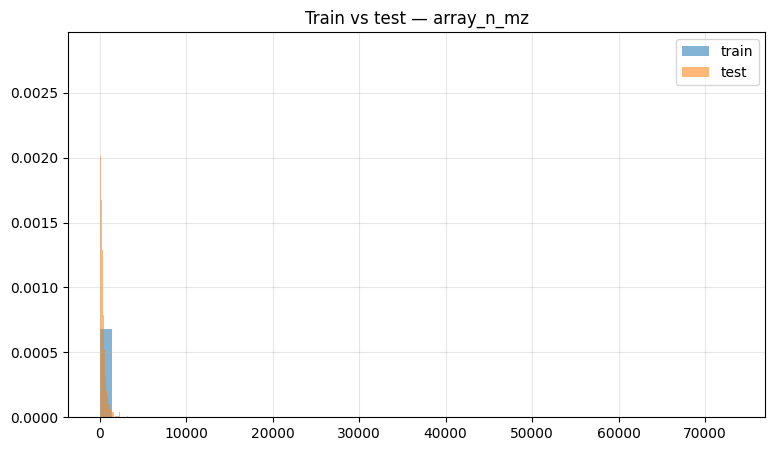

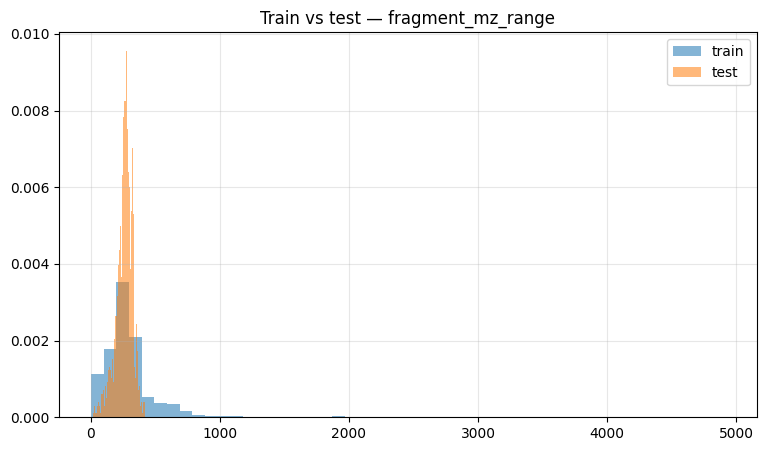

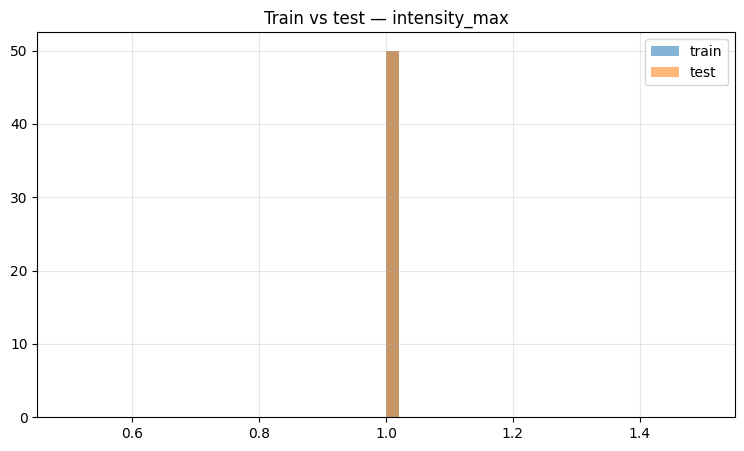

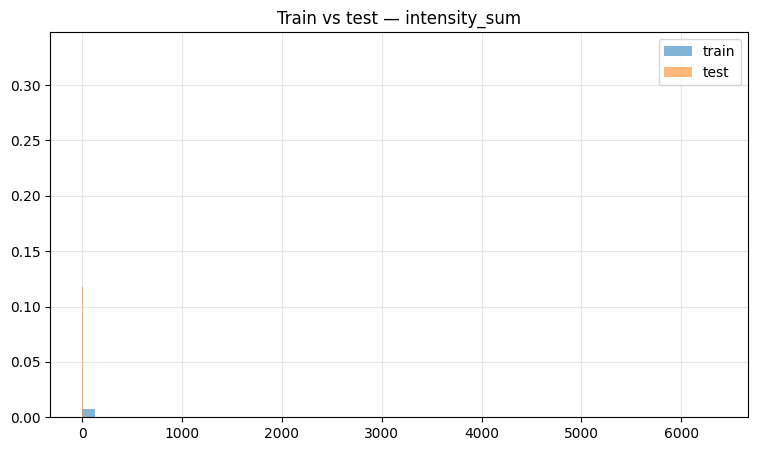

In [9]:
# ---------- 4.6 Raw MS/MS arrays and internal consistency ----------

def spectral_array_audit(df):
    rows = []

    mz_values = df[peaks_col].values
    int_values = df[peaks_intensity_col].values
    precursor_values = (
        pd.to_numeric(df[mz_col], errors="coerce").values
        if mz_col in df.columns else np.full(len(df), np.nan)
    )

    for mz_x, int_x, precursor in zip(mz_values, int_values, precursor_values):
        mz = np.asarray(mz_x, dtype=float).reshape(-1) if isinstance(mz_x, (list, tuple, np.ndarray)) else np.array([])
        inten = np.asarray(int_x, dtype=float).reshape(-1) if isinstance(int_x, (list, tuple, np.ndarray)) else np.array([])

        n_mz = len(mz)
        n_int = len(inten)
        finite_mz = mz[np.isfinite(mz)]
        finite_int = inten[np.isfinite(inten)]

        rows.append({
            "array_n_mz": n_mz,
            "array_n_intensity": n_int,
            "array_length_match": n_mz == n_int,

            "fragment_mz_min": float(finite_mz.min()) if len(finite_mz) else np.nan,
            "fragment_mz_max": float(finite_mz.max()) if len(finite_mz) else np.nan,
            "fragment_mz_mean": float(finite_mz.mean()) if len(finite_mz) else np.nan,
            "fragment_mz_range": float(finite_mz.max() - finite_mz.min()) if len(finite_mz) else np.nan,

            "intensity_min": float(finite_int.min()) if len(finite_int) else np.nan,
            "intensity_max": float(finite_int.max()) if len(finite_int) else np.nan,
            "intensity_mean": float(finite_int.mean()) if len(finite_int) else np.nan,
            "intensity_sum": float(finite_int.sum()) if len(finite_int) else np.nan,

            "has_nan_mz": bool(np.isnan(mz).any()) if len(mz) else False,
            "has_nan_intensity": bool(np.isnan(inten).any()) if len(inten) else False,
            "has_nonpositive_intensity": bool((finite_int <= 0).any()) if len(finite_int) else False,
            "mz_sorted": bool(np.all(np.diff(finite_mz) >= 0)) if len(finite_mz) > 1 else True,
            "fragment_above_precursor": (
                bool((finite_mz > precursor + 0.5).any())
                if len(finite_mz) and np.isfinite(precursor) else False
            ),
        })

    return pd.DataFrame(rows)

train_array_audit = spectral_array_audit(train_df)
test_array_audit = spectral_array_audit(test_df)

print("TRAIN spectral-array audit:")
display(
    train_array_audit.describe(include="all").T
)

print("\nCore integrity checks:")
print("Empty spectra                :", int(train_array_audit["array_n_mz"].eq(0).sum()))
print("m/z-intensity length mismatch:", int((~train_array_audit["array_length_match"]).sum()))
print("Unsorted m/z arrays          :", int((~train_array_audit["mz_sorted"]).sum()))
print("NaN inside m/z arrays        :", int(train_array_audit["has_nan_mz"].sum()))
print("NaN inside intensity arrays  :", int(train_array_audit["has_nan_intensity"].sum()))
print("Non-positive intensities     :", int(train_array_audit["has_nonpositive_intensity"].sum()))
print("Fragment > precursor +0.5 Da:", int(train_array_audit["fragment_above_precursor"].sum()))

if num_peaks_col in train_df.columns:
    num_peaks_numeric = pd.to_numeric(train_df[num_peaks_col], errors="coerce")
    mismatch_num_peaks = (
        num_peaks_numeric.notna()
        & (num_peaks_numeric != train_array_audit["array_n_mz"])
    )
    print(
        f"num_peaks != len(ms2_mzs)    : "
        f"{mismatch_num_peaks.sum():,} ({mismatch_num_peaks.mean()*100:.2f}%)"
    )

for c in ["array_n_mz", "fragment_mz_range", "intensity_max", "intensity_sum"]:
    fig, ax = plt.subplots()
    ax.hist(train_array_audit[c].dropna(), bins=50, density=True, alpha=.55, label="train")
    ax.hist(test_array_audit[c].dropna(), bins=50, density=True, alpha=.55, label="test")
    ax.set_title(f"Train vs test — {c}")
    ax.legend()
    plt.show()


Spearman correlation among acquisition / spectral summaries:


,precursor_mz,precursor_error_ppm,num_peaks,base_peak_intensity,ce_mean,ce_min,ce_max,ce_range,ce_n_steps,array_n_mz,fragment_mz_min,fragment_mz_max,fragment_mz_range,intensity_max,intensity_mean,intensity_sum
precursor_mz,1.0000,-0.2476,-0.0802,-0.2484,0.1917,0.1605,0.2021,0.0366,-0.0286,-0.0802,0.2649,0.7691,0.5193,NaN,0.0578,-0.1074
precursor_error_ppm,-0.2476,1.0000,-0.4065,-0.2228,-0.2293,-0.1786,-0.2443,-0.1034,-0.0543,-0.4065,0.1164,-0.2406,-0.3149,NaN,0.4175,-0.1078
num_peaks,-0.0802,-0.4065,1.0000,0.5478,0.2894,0.1682,0.3509,0.2699,0.1670,1.0000,-0.5479,0.1224,0.4408,NaN,-0.9248,0.4894
base_peak_intensity,-0.2484,-0.2228,0.5478,1.0000,-0.1074,-0.1762,0.0115,0.1691,0.2114,0.5478,-0.3503,-0.0777,0.1198,NaN,-0.6481,-0.0575
ce_mean,0.1917,-0.2293,0.2894,-0.1074,1.0000,0.8850,0.9055,0.0308,-0.0090,0.2894,-0.1504,-0.0479,0.0709,NaN,-0.2278,0.2332
ce_min,0.1605,-0.1786,0.1682,-0.1762,0.8850,1.0000,0.6313,-0.4036,-0.4360,0.1682,-0.0533,-0.1015,-0.0339,NaN,-0.1171,0.1530
ce_max,0.2021,-0.2443,0.3509,0.0115,0.9055,0.6313,1.0000,0.4206,0.3745,0.3509,-0.2070,0.0303,0.1685,NaN,-0.2915,0.2608
ce_range,0.0366,-0.1034,0.2699,0.1691,0.0308,-0.4036,0.4206,1.0000,0.9823,0.2699,-0.2113,0.1550,0.2615,NaN,-0.2611,0.1475
ce_n_steps,-0.0286,-0.0543,0.1670,0.2114,-0.0090,-0.4360,0.3745,0.9823,1.0000,0.1670,-0.1972,-0.0043,0.0658,NaN,-0.1988,0.0182
array_n_mz,-0.0802,-0.4065,1.0000,0.5478,0.2894,0.1682,0.3509,0.2699,0.1670,1.0000,-0.5479,0.1224,0.4408,NaN,-0.9248,0.4894


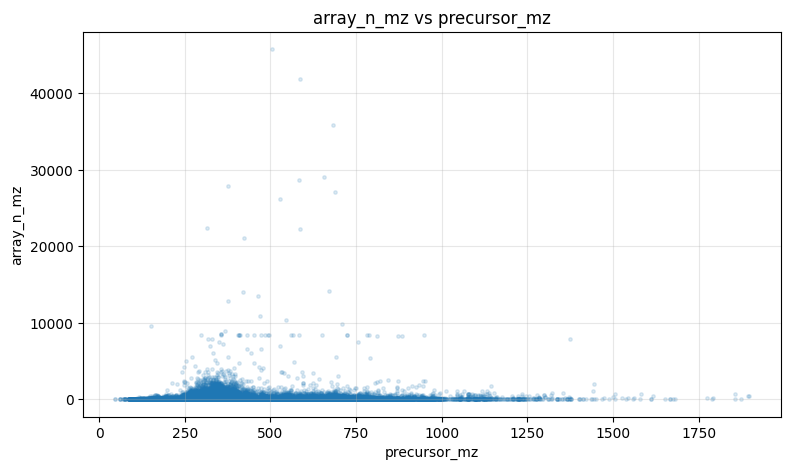

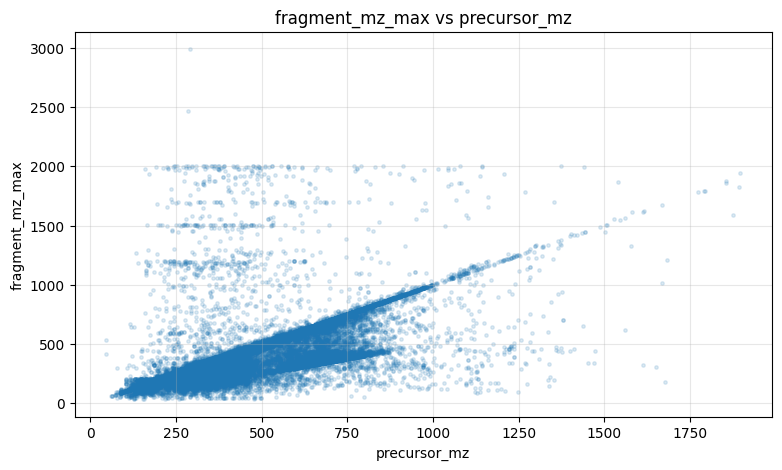

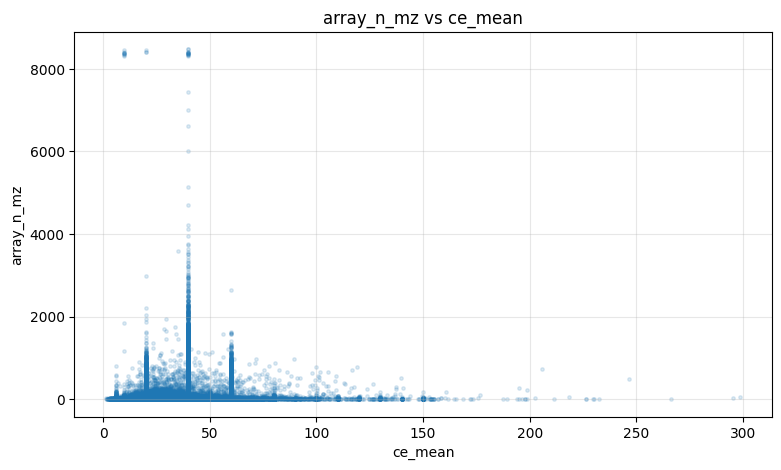

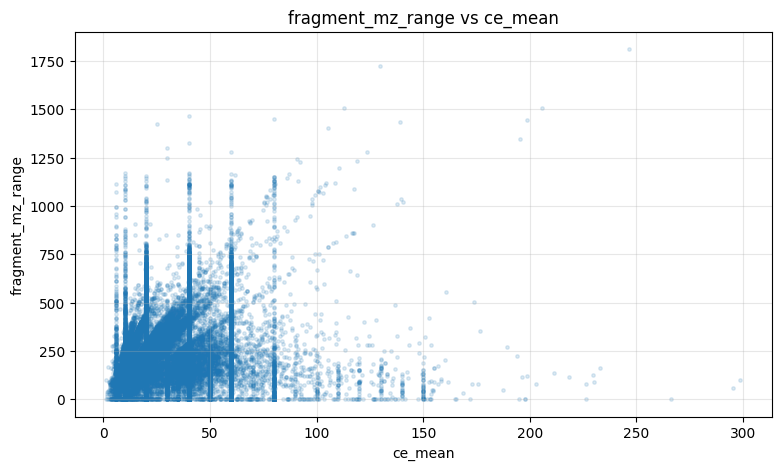


Conditional summaries by ionization_mode:


precursor_mz                   num_peaks                  _ce_ce_mean                 _spec_fragment_mz_range                  
                       count   median     mean     count  median     mean       count  median    mean                   count   median     mean
ionization_mode                                                                                                                                
negative              639968 355.1576 413.1078    639968 23.0000 102.1130      566878 40.0000 35.2605                  639968 263.5865 279.2482
positive             1899640 349.0546 422.0138   1899640 54.0000 177.1163     1635287 40.0000 37.1905                 1899640 263.2830 291.7618


Conditional summaries by instrument_type:


precursor_mz                   num_peaks                     _ce_ce_mean                 _spec_fragment_mz_range                  
                                        count   median     mean     count   median       mean       count  median    mean                   count   median     mean
instrument_type                                                                                                                                                    
                                          297 288.0488 292.8291       297   8.0000    10.0707           0     NaN     NaN                     297 139.9472 165.7472
APCI-ITFT                                 276 248.0706 299.1833       276   9.0000    16.8261         276 18.1000 24.2837                     276 100.5224 143.2329
APCI-ITTOF                                  3 353.1871 353.1867         3   7.0000     7.0000           3 28.3000 28.3000                       3 209.1080 209.1078
DIRECT INFUSION NANOESI-ION TRAP            1 646.6000 646.6000         1  10.0000    10.0000           0     NaN     NaN                       1 391.3000 391.3000
ESI-FT                                    122 420.2030 350.1424       122   2.0000     3.5246         112 32.6000 36.6821                     122  76.8720  90.9084
ESI-ITFT                                  140 228.0731 321.8471       140   6.0000    13.4571         129 15.8000 20.6457                     140 101.0485 185.4893
ESI-ITTOF                                   9 337.1071 381.3620         9  14.0000    32.3333           6 39.3750 39.3750                       9 219.0550 261.9825
ESI-QFT                                 77342 407.2800 475.6117     77342 286.0000   345.4546       56178 37.4000 44.0770                   77342 339.5796 400.3751
ESI-QQ                                      6 525.2860 537.9336         6  42.0000    48.0000           6 22.5000 22.5000                       6 387.0000 386.3500
ESI-QTOF                                 5708 324.1594 378.2945      5708  17.0000 1,944.6752        3644 20.0000 26.1841                    5708 204.0942 427.0863
ESI-TOF                                  1219 353.2330 357.2618      1219  38.0000    46.4692         672  6.0000  8.4926                    1219 315.6582 377.5656
FAB-BE                                      1 252.1230 252.1230         1  99.0000    99.0000           1  5.0000  5.0000                       1 421.9000 421.9000
FAB-EBEB                                  340 582.4100 572.0559       340 319.0000   666.0265           0     NaN     NaN                     340 564.8035 556.8774
Flow-injection QqQ/MS                    8721 321.2700 345.8042      8721   5.0000     6.6294        5556 30.0000 28.9381                    8721  85.0000 118.9654
GC-APCI-QTOF                               78 228.5973 241.5380        78   3.0000     4.1410          78 30.0000 26.1538                      78  34.9675  48.3087
GC-EI-Q                                    35 313.0000 311.4594        35  87.0000    87.9429           0     NaN     NaN                      35 272.0000 300.6286
Hybrid FT                                9137 312.0660 337.8091      9137  31.0000    55.7187           0     NaN     NaN                    9137 173.1418 195.3074
Hybrid Ft                                   5 881.3230 883.7512         5 200.0000   177.4000           0     NaN     NaN                       5 617.9657 886.0083
Ion Trap                                 1958 331.6315 463.6168      1958  40.0000    87.9377           0     NaN     NaN                    1958 235.9267 330.0839
LC-APCI-ITFT                              153 325.1640 337.2681       153  42.0000    43.6993         153 20.3000 24.6706                     153 228.0990 214.2490
LC-APCI-QFT                               130 241.6543 253.0031       130  16.0000    18.9692         130 21.7500 22.7704                     130 175.5660 179.4636
LC-APPI-QQ                                986 285.2000 310.5610       986 141.0000   145.5862    


Conditional summaries by adduct:


precursor_mz                   num_peaks                  _ce_ce_mean                 _spec_fragment_mz_range                  
                      count   median     mean     count  median     mean       count  median    mean                   count   median     mean
adduct                                                                                                                                        
[2M+C2H4N]+               2 626.1820 626.1820         2 59.5000  59.5000           0     NaN     NaN                       2 569.9079 569.9079
[2M+C2H4O2-H]-          187 683.3335 674.2489       187 26.0000  62.2567         187 40.0000 38.8770                     187 390.9832 397.2188
[2M+CH2O2-H]-           665 773.3760 769.2766       665 17.0000  42.6692         661 40.0000 39.3828                     665 274.1141 335.8953
[2M+Ca-H]+                5 723.3620 819.4140         5 14.0000  34.4000           0     NaN     NaN                       5 438.0061 565.9746
[2M+Ca]2+                33 504.2240 513.7778        33 11.0000  29.1212           0     NaN     NaN                      33 435.7340 576.8831
[2M+H-O2]+                2 213.0910 213.0910         2  6.5000   6.5000           2 15.0000 15.0000                       2  82.0863  82.0863
[2M+H]+               92041 681.3872 685.7514     92041 41.0000  84.4337       89570 40.0000 39.6747                   92041 361.0344 414.6548
[2M+K]+                 109 779.1430 803.1757       109 19.0000 193.2752           3 36.2000 33.7222                     109 517.5820 671.3544
[2M+NH4]+               378 842.3380 845.2438       378 46.0000 100.1905           6 45.1333 44.6111                     378 486.8190 699.5248
[2M+Na-2H]-            1431 437.1443 560.6792      1431 41.0000 105.9490           1 15.0000 15.0000                    1431 317.0845 442.5490
[2M+Na-H2O]+              1 273.0969 273.0969         1 29.0000  29.0000           1 15.0000 15.0000                       1 407.2400 407.2400
[2M+Na-H5N]-              1 296.0864 296.0864         1 44.0000  44.0000           1 15.0000 15.0000                       1 878.8096 878.8096
[2M+Na-O2]+               1 235.0730 235.0730         1 12.0000  12.0000           1 15.0000 15.0000                       1 121.8599 121.8599
[2M+Na-O3]+               1 251.0679 251.0679         1 12.0000  12.0000           1 15.0000 15.0000                       1 134.2439 134.2439
[2M+Na2-H3]+              1 309.0316 309.0316         1 44.0000  44.0000           1 15.7000 15.7000                       1 880.3695 880.3695
[2M+Na2-H]+               2 829.4305 829.4305         2 10.5000  10.5000           0     NaN     NaN                       2 451.8605 451.8605
[2M+Na3-H4]-              1 331.0136 331.0136         1 59.0000  59.0000           1 17.3000 17.3000                       1 940.9811 940.9811
[2M+Na]+             190033 687.3590 687.3021    190033 33.0000  67.9625      188182 40.0000 38.7944                  190033 389.1023 401.3960
[2M-H3O2]+               14 785.2610 692.9663        14 72.0000 108.1429           2 15.9500 15.9500                      14 528.2316 925.0221
[2M-H3]-                  1 263.0826 263.0826         1 67.0000  67.0000           1 15.0000 15.0000                       1 938.4709 938.4709
[2M-H5O3]+                1 451.1360 451.1360         1  2.0000   2.0000           0     NaN     NaN                       1 346.9800 346.9800
[2M-HO]+                 19 803.2720 709.0249        19 74.0000 117.5789           5 18.2000 20.6400                      19 437.1758 797.0339
[2M-H]+                   4 253.0494 340.0723         4 24.5000  29.0000           4 15.0000 19.3250                       4 208.0430 354.3028
[2M-H]-               56172 669.1589 666.4944     56172 46.0000 156.8859       53033 40.0000 39.6193                   56172 350.8306 390.7128
[3M+Ca-H]+                2 687.3640 687.3640         2 46.0000  46.0000           0     NaN     NaN                       2 478.7117 478.7117


Conditional summaries by ingest_lib:


precursor_mz                   num_peaks                   _ce_ce_mean                 _spec_fragment_mz_range                  
                          count   median     mean     count   median     mean       count  median    mean                   count   median     mean
ingest_lib                                                                                                                                         
drug_plus                  2545 322.1761 345.7238      2545 108.0000 112.3391           0     NaN     NaN                    2545 249.0327 270.7337
enveda-180              1153785 347.2341 432.6840   1153785 138.0000 246.5049     1153785 40.0000 41.3603                 1153785 278.0697 300.7332
enveda-np-examples         1184 387.6514 426.2035      1184 141.5000 256.5667        1184 40.0000 44.6509                    1184 292.9226 328.4194
gnps                     220849 363.1460 399.7761    220849  46.0000 218.5045           0     NaN     NaN                  220849 286.2336 369.0947
masaryk                     652 295.1572 304.3942       652   9.0000  11.0567           0     NaN     NaN                     652 165.4065 186.7171
massbank                 101727 297.1234 337.7593    101727  11.0000  25.9556       99815 30.0000 38.0312                  101727 135.0535 174.6692
mona                      92416 334.2377 416.0101     92416  57.0000 293.5536       76671 30.0000 34.2692                   92416 252.7557 400.1351
msdial                    40765 374.1598 439.2834     40765  11.0000  42.9666       23780 30.0000 29.9215                   40765 188.2600 273.2978
pluskal_ms2              527581 343.1111 369.4816    527581  21.0000  35.0692      527581 24.2500 27.0247                  527581 258.1226 255.2991
riken                    347171 399.1400 450.1290    347171   9.0000  36.6695      315491 30.0000 36.4879                  347171 153.0450 215.6473
spectraverse              50933 748.5287 687.9011     50933  47.0000 113.5950        3858 24.6500 33.0263                   50933 575.8548 546.0342

In [10]:
# ---------- 4.7 Relationships among the observable variables ----------

observable_numeric = pd.DataFrame(index=train_df.index)

for c in [mz_col, ppm_col, num_peaks_col, base_peak_intensity_col]:
    if c in train_df.columns:
        observable_numeric[c] = pd.to_numeric(train_df[c], errors="coerce")

if len(train_ce_features):
    for c in ["ce_mean", "ce_min", "ce_max", "ce_range", "ce_n_steps"]:
        observable_numeric[c] = train_ce_features[c].values

for c in ["array_n_mz", "fragment_mz_min", "fragment_mz_max", "fragment_mz_range",
          "intensity_max", "intensity_mean", "intensity_sum"]:
    if c in train_array_audit.columns:
        observable_numeric[c] = train_array_audit[c].values

print("Spearman correlation among acquisition / spectral summaries:")
display(observable_numeric.corr(method="spearman"))

# High-value bivariate plots. Sample only for visualization, not for statistics.
plot_df = observable_numeric.copy()
if len(plot_df) > 50_000:
    plot_df = plot_df.sample(50_000, random_state=SEED)

pairs = [
    (mz_col, "array_n_mz"),
    (mz_col, "fragment_mz_max"),
    ("ce_mean", "array_n_mz"),
    ("ce_mean", "fragment_mz_range"),
]

for x, y in pairs:
    if x in plot_df.columns and y in plot_df.columns:
        d = plot_df[[x, y]].dropna()
        if len(d):
            fig, ax = plt.subplots()
            ax.scatter(d[x], d[y], s=6, alpha=.15)
            ax.set_xlabel(x)
            ax.set_ylabel(y)
            ax.set_title(f"{y} vs {x}")
            plt.show()

# Conditional summaries for categorical acquisition variables.
condition_df = pd.concat(
    [
        train_df.reset_index(drop=True),
        train_ce_features.add_prefix("_ce_").reset_index(drop=True)
        if len(train_ce_features) else pd.DataFrame(index=np.arange(len(train_df))),
        train_array_audit.add_prefix("_spec_").reset_index(drop=True),
    ],
    axis=1
)

for c in [ion_col, inst_col, adduct_col, library_col]:
    if c in condition_df.columns:
        metrics = [x for x in [mz_col, num_peaks_col, "_ce_ce_mean", "_spec_fragment_mz_range"] if x in condition_df.columns]
        if metrics:
            summary = condition_df.groupby(c, dropna=False)[metrics].agg(["count", "median", "mean"])
            print(f"\nConditional summaries by {c}:")
            display(summary.head(25))


## 5. Molecule-level analysis

Canonicalize every training SMILES with RDKit, and derive a rich set of structural
descriptors. We keep `raw_smiles`, `canonical_smiles`, and `connectivity_key` as
**separate** columns — we never overwrite the original label.

Because CASMI scoring is connectivity-based (after tautomer canonicalization), we also
attempt a tautomer-canonicalized `connectivity_key` (InChIKey14) when RDKit's tautomer
enumerator is available, falling back gracefully to a plain InChIKey14 otherwise.


In [11]:

def canonicalize_smiles(smiles):
    """Return RDKit-canonical SMILES, or None if parsing fails."""
    if not RDKIT_AVAILABLE or smiles is None or (isinstance(smiles, float) and np.isnan(smiles)):
        return None
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)


_tautomer_enumerator = None
def _get_tautomer_enumerator():
    global _tautomer_enumerator
    if _tautomer_enumerator is None and RDKIT_AVAILABLE:
        try:
            from rdkit.Chem.MolStandardize import rdMolStandardize
            _tautomer_enumerator = rdMolStandardize.TautomerEnumerator()
        except Exception:
            _tautomer_enumerator = False  # sentinel: unavailable
    return _tautomer_enumerator


def get_connectivity_key(smiles, use_tautomer_canon=True):
    """Best-effort competition-like connectivity key: InChIKey14 (first 14 chars),
    optionally after tautomer canonicalization if the installed RDKit supports it.
    Falls back to plain InChIKey14 (no tautomer canon) if unavailable.
    """
    if not RDKIT_AVAILABLE or smiles is None:
        return None
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    if use_tautomer_canon:
        enumerator = _get_tautomer_enumerator()
        if enumerator and enumerator is not False:
            try:
                mol = enumerator.Canonicalize(mol)
            except Exception:
                pass
    try:
        inchi = Chem.MolToInchi(mol)
        inchikey = Chem.InchiToInchiKey(inchi)
        if inchikey:
            return inchikey.split("-")[0]  # InChIKey14 = connectivity block
    except Exception:
        return None
    return None


def compute_molecule_descriptors(smiles):
    """Return a dict of structural descriptors for one SMILES, or all-NaN dict if invalid."""
    out = dict(
        canonical_smiles=None, inchikey=None, inchikey14=None, molecular_formula=None,
        exact_mass=np.nan, molecular_weight=np.nan, num_atoms=np.nan, num_heavy_atoms=np.nan,
        num_rings=np.nan, num_aromatic_rings=np.nan, num_heteroatoms=np.nan,
        num_rotatable_bonds=np.nan, formal_charge=np.nan,
    )
    if not RDKIT_AVAILABLE or smiles is None:
        return out
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return out
    try:
        out["canonical_smiles"] = Chem.MolToSmiles(mol, canonical=True)
        inchi = Chem.MolToInchi(mol)
        inchikey = Chem.InchiToInchiKey(inchi)
        out["inchikey"] = inchikey
        out["inchikey14"] = inchikey.split("-")[0] if inchikey else None
        out["molecular_formula"] = rdMolDescriptors.CalcMolFormula(mol)
        out["exact_mass"] = Descriptors.ExactMolWt(mol)
        out["molecular_weight"] = Descriptors.MolWt(mol)
        out["num_atoms"] = mol.GetNumAtoms()
        out["num_heavy_atoms"] = mol.GetNumHeavyAtoms()
        out["num_rings"] = rdMolDescriptors.CalcNumRings(mol)
        out["num_aromatic_rings"] = rdMolDescriptors.CalcNumAromaticRings(mol)
        out["num_heteroatoms"] = rdMolDescriptors.CalcNumHeteroatoms(mol)
        out["num_rotatable_bonds"] = rdMolDescriptors.CalcNumRotatableBonds(mol)
        out["formal_charge"] = Chem.GetFormalCharge(mol)
    except Exception:
        pass
    return out

print("Reusable functions ready: canonicalize_smiles, get_connectivity_key, compute_molecule_descriptors")


Reusable functions ready: canonicalize_smiles, get_connectivity_key, compute_molecule_descriptors


In [14]:
# ============================================================
# FIX STRUCTURE IDENTIFIERS + SCAFFOLDS
# ROBUST TO DUPLICATE COLUMN NAMES
# ============================================================

import numpy as np
import pandas as pd

struct_df = struct_df.copy()


# ============================================================
# 1. PHYSICALLY COLLAPSE DUPLICATE COLUMNS
# ============================================================

def collapse_duplicate_columns(df):
    """
    For duplicate column names, coalesce left -> right using the
    first non-null value per row, then return a DataFrame with
    UNIQUE column names.
    """

    duplicate_names = (
        pd.Index(df.columns)[
            pd.Index(df.columns).duplicated(keep=False)
        ]
        .unique()
        .tolist()
    )

    if duplicate_names:
        print("Duplicate columns detected:")
        for c in duplicate_names:
            print(
                f"  {c!r}: "
                f"{sum(df.columns == c)} occurrences"
            )

    result = {}

    # preserve original column order
    unique_names = list(dict.fromkeys(df.columns.tolist()))

    for col in unique_names:

        positions = np.flatnonzero(
            np.asarray(df.columns, dtype=object) == col
        )

        # guaranteed Series because positional selection
        s = df.iloc[:, positions[0]].copy()

        for pos in positions[1:]:
            other = df.iloc[:, pos]
            s = s.combine_first(other)

        result[col] = s

    out = pd.DataFrame(
        result,
        index=df.index
    )

    assert not out.columns.duplicated().any()

    return out


struct_df = collapse_duplicate_columns(struct_df)

print(
    "\nDuplicate columns remaining:",
    struct_df.columns.duplicated().sum()
)


# ============================================================
# 2. HELPERS
# ============================================================

def empty_series(df):
    return pd.Series(
        np.nan,
        index=df.index,
        dtype="object"
    )


def safe_col(df, col):
    """
    Always return one Series.
    """
    if col is None or col not in df.columns:
        return empty_series(df)

    return df[col].copy()


def clean_string(s):
    return (
        s
        .replace(
            [
                "",
                " ",
                "None",
                "none",
                "NULL",
                "null",
                "NaN",
                "nan",
                "<NA>",
            ],
            np.nan
        )
    )


# ============================================================
# 3. RECOVER / CREATE CORE COLUMNS
# ============================================================

# raw smiles
if "raw_smiles" in struct_df.columns:
    raw_smiles = clean_string(
        struct_df["raw_smiles"]
    )

elif "smiles" in struct_df.columns:
    raw_smiles = clean_string(
        struct_df["smiles"]
    )

else:
    raw_smiles = empty_series(struct_df)


# canonical smiles
canonical_smiles = clean_string(
    safe_col(
        struct_df,
        "canonical_smiles"
    )
)


# full InChIKey
inchikey = clean_string(
    safe_col(
        struct_df,
        "inchikey"
    )
)


# existing connectivity block
inchikey14_existing = clean_string(
    safe_col(
        struct_df,
        "inchikey14"
    )
)


# existing molecule key
molecule_key_existing = clean_string(
    safe_col(
        struct_df,
        "molecule_key"
    )
)


# ============================================================
# 4. DERIVE InChIKey14
# ============================================================

inchikey14_derived = (
    inchikey
    .astype("string")
    .str.split("-")
    .str[0]
    .replace("<NA>", np.nan)
)

inchikey14 = (
    inchikey14_existing
    .combine_first(inchikey14_derived)
)

struct_df["inchikey14"] = inchikey14


# ============================================================
# 5. OPTIONAL mol_col FALLBACK
# ============================================================

if (
    mol_col is not None
    and mol_col in struct_df.columns
):

    mol_series = clean_string(
        struct_df[mol_col]
    )

else:

    mol_series = empty_series(
        struct_df
    )


# ============================================================
# 6. CONNECTIVITY IDENTIFIER
# ============================================================
#
# Priority:
#
# 1. InChIKey connectivity block
# 2. existing molecule_key
# 3. mol_col
# 4. canonical SMILES
# 5. raw SMILES
#
# ============================================================

connectivity_key = (
    inchikey14
    .combine_first(molecule_key_existing)
    .combine_first(mol_series)
    .combine_first(canonical_smiles)
    .combine_first(raw_smiles)
)

struct_df["connectivity_key"] = connectivity_key


# Stable key used downstream
struct_df["molecule_key"] = connectivity_key


# Ensure SMILES output columns exist
struct_df["raw_smiles"] = raw_smiles
struct_df["canonical_smiles"] = canonical_smiles


# ============================================================
# 7. SCAFFOLD
# ============================================================

scaffold_existing = clean_string(
    safe_col(
        struct_df,
        "scaffold_smiles"
    )
)

murcko_existing = clean_string(
    safe_col(
        struct_df,
        "murcko_scaffold"
    )
)

scaffold_smiles = (
    scaffold_existing
    .combine_first(murcko_existing)
)

struct_df["scaffold_smiles"] = scaffold_smiles


# ============================================================
# 8. COMPUTE MISSING MURCKO SCAFFOLDS
# ============================================================

if RDKIT_AVAILABLE:

    from rdkit import Chem
    from rdkit.Chem.Scaffolds import MurckoScaffold

    def compute_murcko(smiles):

        if pd.isna(smiles):
            return np.nan

        try:

            mol = Chem.MolFromSmiles(
                str(smiles)
            )

            if mol is None:
                return np.nan

            scaffold = (
                MurckoScaffold
                .GetScaffoldForMol(mol)
            )

            # Acyclic compound
            if (
                scaffold is None
                or scaffold.GetNumAtoms() == 0
            ):
                return np.nan

            return Chem.MolToSmiles(
                scaffold,
                canonical=True
            )

        except Exception:
            return np.nan


    missing_scaffold = (
        struct_df["scaffold_smiles"]
        .isna()
    )

    print(
        "\nMissing scaffolds before RDKit:",
        f"{missing_scaffold.sum():,}"
    )

    if missing_scaffold.any():

        struct_df.loc[
            missing_scaffold,
            "scaffold_smiles"
        ] = (
            struct_df.loc[
                missing_scaffold,
                "canonical_smiles"
            ]
            .apply(compute_murcko)
        )


# ============================================================
# 9. VALID STRUCTURE
# ============================================================

struct_df["valid_structure"] = (
    struct_df["canonical_smiles"].notna()
    & struct_df["connectivity_key"].notna()
)


# ============================================================
# 10. VALID SUBSET + STATISTICS
# ============================================================

valid_struct = (
    struct_df.loc[
        struct_df["valid_structure"]
    ]
    .copy()
)

n_struct = (
    valid_struct["connectivity_key"]
    .dropna()
    .nunique()
)

n_scaffold = (
    valid_struct["scaffold_smiles"]
    .replace("", np.nan)
    .dropna()
    .nunique()
)


print("\n" + "=" * 70)
print("STRUCTURE IDENTIFIER SUMMARY")
print("=" * 70)

print(
    f"Rows in structure table : {len(struct_df):,}"
)

print(
    f"Valid structures        : {len(valid_struct):,}"
)

print(
    f"Unique connectivities   : {n_struct:,}"
)

print(
    f"Unique scaffolds        : {n_scaffold:,}"
)


# ============================================================
# 11. InChIKey14 SANITY CHECK
# ============================================================

key14 = (
    struct_df["inchikey14"]
    .dropna()
    .astype(str)
)

bad_length = (
    key14.str.len() != 14
).sum()

print(
    f"Invalid InChIKey14      : {bad_length:,}"
)


# ============================================================
# 12. COVERAGE
# ============================================================

print("\nIdentifier coverage:")

for col in [
    "raw_smiles",
    "canonical_smiles",
    "inchikey",
    "inchikey14",
    "connectivity_key",
    "molecule_key",
    "scaffold_smiles",
]:

    if col in struct_df.columns:

        print(
            f"{col:<24}: "
            f"{struct_df[col].notna().sum():>8,} / "
            f"{len(struct_df):,}"
        )


# ============================================================
# 13. FINAL ASSERTIONS
# ============================================================

assert not struct_df.columns.duplicated().any(), (
    "Duplicate columns still exist."
)

assert isinstance(
    struct_df["inchikey14"],
    pd.Series
)

assert isinstance(
    struct_df["connectivity_key"],
    pd.Series
)

print("\n✓ All column names are unique.")
print("✓ inchikey14 is a Series.")
print("✓ connectivity_key is a Series.")


# ============================================================
# 14. PREVIEW
# ============================================================

display_cols = [
    "raw_smiles",
    "canonical_smiles",
    "inchikey",
    "inchikey14",
    "connectivity_key",
    "molecular_formula",
    "exact_mass",
    "scaffold_smiles",
    "valid_structure",
]

display_cols = [
    c
    for c in display_cols
    if c in struct_df.columns
]

display(
    struct_df[
        display_cols
    ].head(10)
)

Duplicate columns detected:
  'inchikey14': 2 occurrences

Duplicate columns remaining: 0


C:\Users\myben\AppData\Local\Temp\ipykernel_424\1061148335.py:102: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(
C:\Users\myben\AppData\Local\Temp\ipykernel_424\1061148335.py:102: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(
C:\Users\myben\AppData\Local\Temp\ipykernel_424\1061148335.py:102: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `


Missing scaffolds before RDKit: 277,566


C:\Users\myben\AppData\Local\Temp\ipykernel_424\1061148335.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21' 'c1ccc(Nc2ncnc3ccccc23)cc1'
 'C(Cc1ccc2c(c1)CCCC2)=Nc1ccccc1' ... 'O=c1c(Cc2c[nH]c3ccccc23)ncc2n1CCC2'
 'O=c1[nH]cc(Cc2ccccc2)c(=O)[nH]1' nan]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  struct_df.loc[



STRUCTURE IDENTIFIER SUMMARY
Rows in structure table : 277,566
Valid structures        : 277,566
Unique connectivities   : 275,810
Unique scaffolds        : 127,237
Invalid InChIKey14      : 0

Identifier coverage:
raw_smiles              :  277,566 / 277,566
canonical_smiles        :  277,566 / 277,566
inchikey                :  277,566 / 277,566
inchikey14              :  277,566 / 277,566
connectivity_key        :  277,566 / 277,566
molecule_key            :  277,566 / 277,566
scaffold_smiles         :  263,453 / 277,566

✓ All column names are unique.
✓ inchikey14 is a Series.
✓ connectivity_key is a Series.


,raw_smiles,canonical_smiles,inchikey,inchikey14,connectivity_key,molecular_formula,exact_mass,scaffold_smiles,valid_structure
0,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,AAALVYBICLMAMA-UHFFFAOYSA-N,AAALVYBICLMAMA,AAALVYBICLMAMA,C20H15N3O2,329.1164,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,True
1,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,AAKJLRGGTJKAMG-UHFFFAOYSA-N,AAKJLRGGTJKAMG,AAKJLRGGTJKAMG,C22H23N3O4,393.1689,c1ccc(Nc2ncnc3ccccc23)cc1,True
2,CC1(C)CCC(C)(C)c2cc(C(O)C(O)=Nc3ccc(C(=O)O)cc3F)ccc21,CC1(C)CCC(C)(C)c2cc(C(O)C(O)=Nc3ccc(C(=O)O)cc3F)ccc21,AANFHDFOMFRLLR-UHFFFAOYSA-N,AANFHDFOMFRLLR,AANFHDFOMFRLLR,C23H26FNO4,399.1846,C(Cc1ccc2c(c1)CCCC2)=Nc1ccccc1,True
3,CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21,CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21,AAOVKJBEBIDNHE-UHFFFAOYSA-N,AAOVKJBEBIDNHE,AAOVKJBEBIDNHE,C16H13ClN2O,284.0716,O=C1CN=C(c2ccccc2)c2ccccc2N1,True
4,NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)C=CC1,NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)C=CC1,ACFIXJIJDZMPPO-UHFFFAOYSA-N,ACFIXJIJDZMPPO,ACFIXJIJDZMPPO,C21H30N7O17P3,745.0911,O=[PH](OCC1CCC(N2C=CCC=C2)O1)O[PH](=O)OCC1CCC(n2cnc3cncnc32)O1,True
5,N=C(N)NCCN1CCCCCCC1,N=C(N)NCCN1CCCCCCC1,ACGDKVXYNVEAGU-UHFFFAOYSA-N,ACGDKVXYNVEAGU,ACGDKVXYNVEAGU,C10H22N4,198.1844,C1CCCNCCC1,True
6,CC(C)(O)C1OC2CCC3(C)C(O)(CCC4Cc5c([nH]c6ccccc56)C43C)C2=CC1=O,CC(C)(O)C1OC2CCC3(C)C(O)(CCC4Cc5c([nH]c6ccccc56)C43C)C2=CC1=O,ACNHBCIZLNNLRS-UHFFFAOYSA-N,ACNHBCIZLNNLRS,ACNHBCIZLNNLRS,C27H33NO4,435.2410,O=C1C=C2C(CCC3C2CCC2Cc4c([nH]c5ccccc45)C23)OC1,True
7,O=C1c2ccccc2-c2n[nH]c3cccc1c23,O=C1c2ccccc2-c2n[nH]c3cccc1c23,ACPOUJIDANTYHO-UHFFFAOYSA-N,ACPOUJIDANTYHO,ACPOUJIDANTYHO,C14H8N2O,220.0637,O=C1c2ccccc2-c2n[nH]c3cccc1c23,True
8,COc1cc2c(cc1OC)CC(=O)N(CCCN(C)CC1Cc3cc(OC)c(OC)cc31)CC2,COc1cc2c(cc1OC)CC(=O)N(CCCN(C)CC1Cc3cc(OC)c(OC)cc31)CC2,ACRHBAYQBXXRTO-UHFFFAOYSA-N,ACRHBAYQBXXRTO,ACRHBAYQBXXRTO,C27H36N2O5,468.2624,O=C1Cc2ccccc2CCN1CCCNCC1Cc2ccccc21,True
9,COC1=C(OC)C(=O)C(CC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)C)=C(C)C1=O,COC1=C(OC)C(=O)C(CC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)CCC=C(C)C)=C(C)C1=O,ACTIUHUUMQJHFO-UHFFFAOYSA-N,ACTIUHUUMQJHFO,ACTIUHUUMQJHFO,C59H90O4,862.6839,O=C1C=CC(=O)C=C1,True


## 6. Detect duplicate or repeated structures

This is one of the most important sections for validation design: if the same molecule
(connectivity) appears many times with different spectra, a naive random split will leak
that molecule's structure between train and validation.


In [15]:

if len(struct_df):
    print("### A. Exact duplicate labels")
    for key in ["raw_smiles", "canonical_smiles", "connectivity_key"]:
        vc = struct_df[key].value_counts()
        n_dupe_groups = (vc > 1).sum()
        n_dupe_rows = vc[vc > 1].sum()
        print(f"  {key:18s}: {n_dupe_groups} duplicated groups covering {n_dupe_rows} rows "
              f"(out of {len(struct_df)})")


### A. Exact duplicate labels
  raw_smiles        : 0 duplicated groups covering 0 rows (out of 277566)
  canonical_smiles  : 0 duplicated groups covering 0 rows (out of 277566)
  connectivity_key  : 1612 duplicated groups covering 3368 rows (out of 277566)


Structure rows                  : 277,566
Unique mol-connectivity pairs  : 275,810
Molecule IDs with >1 connectivity: 0

Unique mapping entries          : 275,810
Mapped train rows               : 2,539,608 / 2,539,608 (100.00%)

### B. Spectra per molecule (by connectivity_key)
count   275,810.0000
mean          9.2078
std          21.0696
min           1.0000
25%           4.0000
50%           6.0000
75%           9.0000
max       1,468.0000
Name: count, dtype: float64

Unique molecular connectivities represented in train: 275,810
Structures with >1 spectrum: 258,777
Structures with exactly 1 spectrum: 17,033


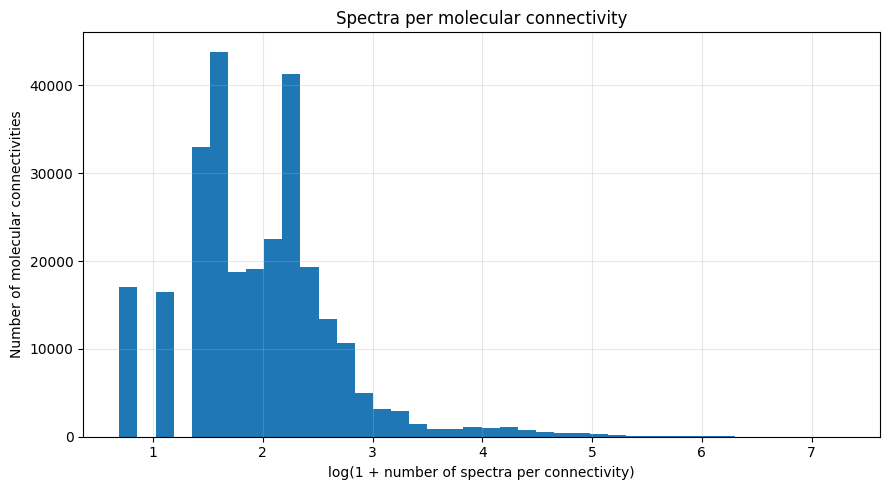

In [17]:
# ============================================================
# SPECTRA PER MOLECULE — ROBUST CONNECTIVITY MAPPING
# ============================================================

if (
    mol_col
    and mol_col in struct_df.columns
    and mol_col in train_df.columns
    and "connectivity_key" in struct_df.columns
):

    # --------------------------------------------------------
    # 1. Build clean molecule -> connectivity table
    # --------------------------------------------------------

    conn_pairs = (
        struct_df[
            [mol_col, "connectivity_key"]
        ]
        .dropna(
            subset=[mol_col, "connectivity_key"]
        )
        .drop_duplicates()
        .copy()
    )

    print("Structure rows                  :", f"{len(struct_df):,}")
    print("Unique mol-connectivity pairs  :", f"{len(conn_pairs):,}")


    # --------------------------------------------------------
    # 2. Check for ambiguous molecule IDs
    # --------------------------------------------------------
    # A mol_col is ambiguous if it maps to >1 connectivity_key.
    # --------------------------------------------------------

    n_conn_per_mol = (
        conn_pairs
        .groupby(
            mol_col,
            sort=False,
            observed=True
        )["connectivity_key"]
        .nunique()
    )

    ambiguous_ids = (
        n_conn_per_mol[
            n_conn_per_mol > 1
        ]
        .index
    )

    n_ambiguous = len(ambiguous_ids)

    print(
        "Molecule IDs with >1 connectivity:",
        f"{n_ambiguous:,}"
    )


    # --------------------------------------------------------
    # 3. Inspect conflicts if they exist
    # --------------------------------------------------------

    if n_ambiguous > 0:

        print(
            "\nWARNING: some molecule IDs map to multiple "
            "connectivity keys."
        )

        conflict_table = (
            conn_pairs[
                conn_pairs[mol_col].isin(
                    ambiguous_ids
                )
            ]
            .sort_values(mol_col)
        )

        display(
            conflict_table.head(30)
        )


    # --------------------------------------------------------
    # 4. KEEP ONLY UNAMBIGUOUS mappings
    # --------------------------------------------------------
    #
    # Important:
    # Do NOT arbitrarily choose first() for ambiguous molecules.
    # --------------------------------------------------------

    valid_pairs = (
        conn_pairs[
            ~conn_pairs[mol_col].isin(
                ambiguous_ids
            )
        ]
        .drop_duplicates(
            subset=[mol_col]
        )
        .copy()
    )

    # Now the mapping index is GUARANTEED unique
    conn_map = (
        valid_pairs
        .set_index(mol_col)["connectivity_key"]
    )

    assert conn_map.index.is_unique

    print(
        "\nUnique mapping entries          :",
        f"{len(conn_map):,}"
    )


    # --------------------------------------------------------
    # 5. Map train spectra -> connectivity
    # --------------------------------------------------------

    spectra_conn = (
        train_df[mol_col]
        .map(conn_map)
    )


    # --------------------------------------------------------
    # 6. Mapping coverage
    # --------------------------------------------------------

    mapped_n = spectra_conn.notna().sum()

    print(
        "Mapped train rows               :",
        f"{mapped_n:,} / {len(train_df):,}",
        f"({100 * mapped_n / len(train_df):.2f}%)"
    )


    # --------------------------------------------------------
    # 7. Spectra per molecular connectivity
    # --------------------------------------------------------

    spectra_per_structure = (
        spectra_conn
        .dropna()
        .value_counts()
    )

    print(
        "\n### B. Spectra per molecule "
        "(by connectivity_key)"
    )

    print(
        spectra_per_structure.describe()
    )


    # --------------------------------------------------------
    # 8. Useful summary
    # --------------------------------------------------------

    print(
        "\nUnique molecular connectivities represented in train:",
        f"{spectra_per_structure.size:,}"
    )

    print(
        "Structures with >1 spectrum:",
        f"{(spectra_per_structure > 1).sum():,}"
    )

    print(
        "Structures with exactly 1 spectrum:",
        f"{(spectra_per_structure == 1).sum():,}"
    )


    # --------------------------------------------------------
    # 9. Distribution plot
    # --------------------------------------------------------

    if len(spectra_per_structure):

        fig, ax = plt.subplots(
            figsize=(9, 5)
        )

        # log1p helps when a few compounds have many spectra
        ax.hist(
            np.log1p(
                spectra_per_structure.values
            ),
            bins=40
        )

        ax.set_xlabel(
            "log(1 + number of spectra per connectivity)"
        )

        ax.set_ylabel(
            "Number of molecular connectivities"
        )

        ax.set_title(
            "Spectra per molecular connectivity"
        )

        plt.tight_layout()
        plt.show()


else:

    print(
        "Cannot build connectivity mapping.\n"
        f"mol_col = {mol_col!r}\n"
        f"mol_col in struct_df: "
        f"{mol_col in struct_df.columns if mol_col else False}\n"
        f"mol_col in train_df : "
        f"{mol_col in train_df.columns if mol_col else False}\n"
        f"connectivity_key available: "
        f"{'connectivity_key' in struct_df.columns}"
    )

In [18]:

print("### C. Why a naive random spectrum-level split may leak")

if len(struct_df) and mol_col and mol_col in train_df.columns:
    rng = np.random.default_rng(SEED)
    n = len(train_df)
    idx = np.arange(n)
    rng.shuffle(idx)
    val_frac = 0.2
    n_val = int(n * val_frac)
    val_idx, tr_idx = idx[:n_val], idx[n_val:]

    conn_all = train_df[mol_col].map(conn_map)
    train_structs = set(conn_all.iloc[tr_idx].dropna())
    val_structs = conn_all.iloc[val_idx].dropna()

    leak_mask = val_structs.isin(train_structs)
    leak_pct = 100 * leak_mask.mean() if len(val_structs) else np.nan

    print(f"Simulated random {int(val_frac*100)}% spectrum-level holdout:")
    print(f"  Validation spectra: {len(val_idx)}")
    print(f"  Validation spectra whose molecule/connectivity ALSO appears in the "
          f"remaining training spectra: {leak_mask.sum()} ({leak_pct:.1f}%)")
    if leak_pct > 5:
        print("\n  -> This is a MEANINGFUL leakage rate. A model could partly succeed on "
              "validation simply by memorizing/retrieving spectra of molecules it has "
              "already seen, inflating validation MRR@25 relative to true test performance "
              "on structurally novel molecules.")
    else:
        print("\n  -> Leakage rate is low in this simulation, but grouped validation is "
              "still the safer default given the 'novel structure' nature of CASMI.")
else:
    print("Skipping -- requires struct_df and molecule_id_col.")


### C. Why a naive random spectrum-level split may leak
Simulated random 20% spectrum-level holdout:
  Validation spectra: 507921
  Validation spectra whose molecule/connectivity ALSO appears in the remaining training spectra: 501995 (98.8%)

  -> This is a MEANINGFUL leakage rate. A model could partly succeed on validation simply by memorizing/retrieving spectra of molecules it has already seen, inflating validation MRR@25 relative to true test performance on structurally novel molecules.


**Observation:** the leakage simulation above quantifies, on the real data, how many
naively-held-out spectra share a molecule with the training partition.

**Why it matters:** MRR@25 measured on a leaky split does not estimate performance on
truly unseen chemistry, which is what the hidden test set actually contains.

**Implication for modeling:** all future CV must group by `connectivity_key`, not split
at the spectrum level (see Section 21–22).


## 7. Molecular scaffold analysis (Bemis–Murcko)

Unique structures: 275810
Unique scaffolds:  127238
Fraction of singleton scaffolds (exactly 1 structure): 73.76%


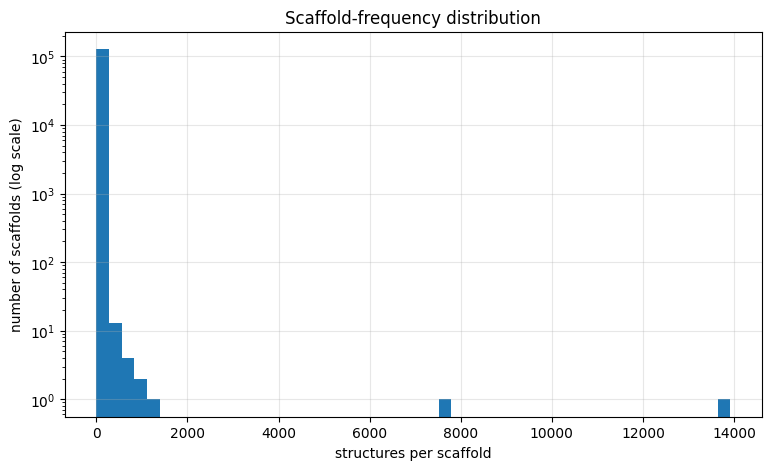


Largest scaffold families:


scaffold_smiles
                               13920
c1ccccc1                        7609
C1CCC2C(C1)CCC1C3CCCC3CCC21     1153
c1ccc2[nH]ccc2c1                1017
C1CCOCC1                         846
C1CCCCC1                         615
O=S(=O)(Nc1ccccc1)c1ccccc1       609
c1c[nH]cn1                       604
O=C(c1ccccc1)N1CCCCC1            579
c1ccncc1                         527
Name: connectivity_key, dtype: int64

In [19]:

def get_murcko_scaffold(smiles):
    if not RDKIT_AVAILABLE or smiles is None:
        return None
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold, canonical=True)
    except Exception:
        return None

if len(struct_df):
    struct_df["murcko_scaffold"] = struct_df["canonical_smiles"].apply(get_murcko_scaffold)
    struct_df = struct_df.rename(columns={"murcko_scaffold": "scaffold_smiles"}) if False else struct_df
    struct_df["scaffold_smiles"] = struct_df["murcko_scaffold"]

    n_struct = struct_df["connectivity_key"].nunique()
    n_scaffold = struct_df["scaffold_smiles"].nunique()
    print(f"Unique structures: {n_struct}")
    print(f"Unique scaffolds:  {n_scaffold}")

    per_scaffold = struct_df.groupby("scaffold_smiles")["connectivity_key"].nunique().sort_values(ascending=False)
    singleton_frac = (per_scaffold == 1).mean()
    print(f"Fraction of singleton scaffolds (exactly 1 structure): {singleton_frac:.2%}")

    fig, ax = plt.subplots()
    ax.hist(per_scaffold.values, bins=min(50, per_scaffold.nunique()))
    ax.set_yscale("log")
    ax.set_xlabel("structures per scaffold")
    ax.set_ylabel("number of scaffolds (log scale)")
    ax.set_title("Scaffold-frequency distribution")
    plt.show()

    print("\nLargest scaffold families:")
    display(per_scaffold.head(10))
else:
    print("Skipping -- requires struct_df from Section 5.")


In [20]:

if len(struct_df) and "scaffold_smiles" in struct_df.columns:
    per_scaffold = struct_df.groupby("scaffold_smiles")["connectivity_key"].nunique().sort_values(ascending=False)
    if len(per_scaffold):
        common_scaffold = per_scaffold.index[0]
        medium_scaffolds = per_scaffold[(per_scaffold >= 2) & (per_scaffold < per_scaffold.iloc[0])]
        medium_scaffold = medium_scaffolds.index[len(medium_scaffolds)//2] if len(medium_scaffolds) else None
        singleton_scaffold = per_scaffold[per_scaffold == 1].index[0] if (per_scaffold == 1).any() else None

        for label, scaf in [("very common", common_scaffold), ("medium-frequency", medium_scaffold), ("singleton", singleton_scaffold)]:
            if scaf is None:
                continue
            examples = struct_df[struct_df["scaffold_smiles"] == scaf][["raw_smiles", "canonical_smiles"]].head(5)
            print(f"\n{label.upper()} scaffold: {scaf}")
            display(examples)



VERY COMMON scaffold: 


,raw_smiles,canonical_smiles
15,NC(CS(=O)O)C(=O)O,NC(CS(=O)O)C(=O)O
21,CCCCCCCCCCCCCCC(O)C(O)C(N)CO,CCCCCCCCCCCCCCC(O)C(O)C(N)CO
22,CCC(CO)NCCNC(CC)CO,CCC(CO)NCCNC(CC)CO
23,CC(O)=NCCCS(=O)(=O)O,CC(O)=NCCCS(=O)(=O)O
30,CCC(C)C(N)C(=O)O,CCC(C)C(N)C(=O)O



MEDIUM-FREQUENCY scaffold: O=C(c1cnn2cccnc12)N1CCNCC1


,raw_smiles,canonical_smiles
25581,O=C(c1cnn2cc(Br)cnc12)N1CCNCC1,O=C(c1cnn2cc(Br)cnc12)N1CCNCC1
55656,CN(C)C(=O)N1CCN(C(=O)c2cnn3cccnc23)C(C)(C)C1,CN(C)C(=O)N1CCN(C(=O)c2cnn3cccnc23)C(C)(C)C1
96982,Cc1nn2cccnc2c1C(=O)N1CCN(C(=O)C(C)C)CC1,Cc1nn2cccnc2c1C(=O)N1CCN(C(=O)C(C)C)CC1



SINGLETON scaffold: O=C1CN(C(=O)c2ccc(NC(=O)C3CC3)cc2)c2ccccc2N1


,raw_smiles,canonical_smiles
17118,CC(F)(F)C1(C(=O)Nc2ccc(C(=O)N3CC(=O)Nc4ccccc43)cc2)CC1,CC(F)(F)C1(C(=O)Nc2ccc(C(=O)N3CC(=O)Nc4ccccc43)cc2)CC1


**Observation:** scaffold frequency distribution and singleton fraction, computed above.

**Why it matters:** high singleton fraction implies most scaffolds are rare -> good test
of generalization but also means scaffold-based CV folds will be small-sample per scaffold.

**Implication for modeling:** use scaffold split as a *secondary, harder* validation on
top of the primary connectivity-grouped split.


## 8. Precursor m/z analysis

count   2,539,608.0000
mean          419.7696
std         1,535.9865
min             2.0000
1%            137.0710
5%            204.0655
25%           308.1410
50%           350.1088
75%           489.2142
95%           775.4660
99%           976.3292
max     2,430,333.0000
Name: precursor_mz, dtype: float64


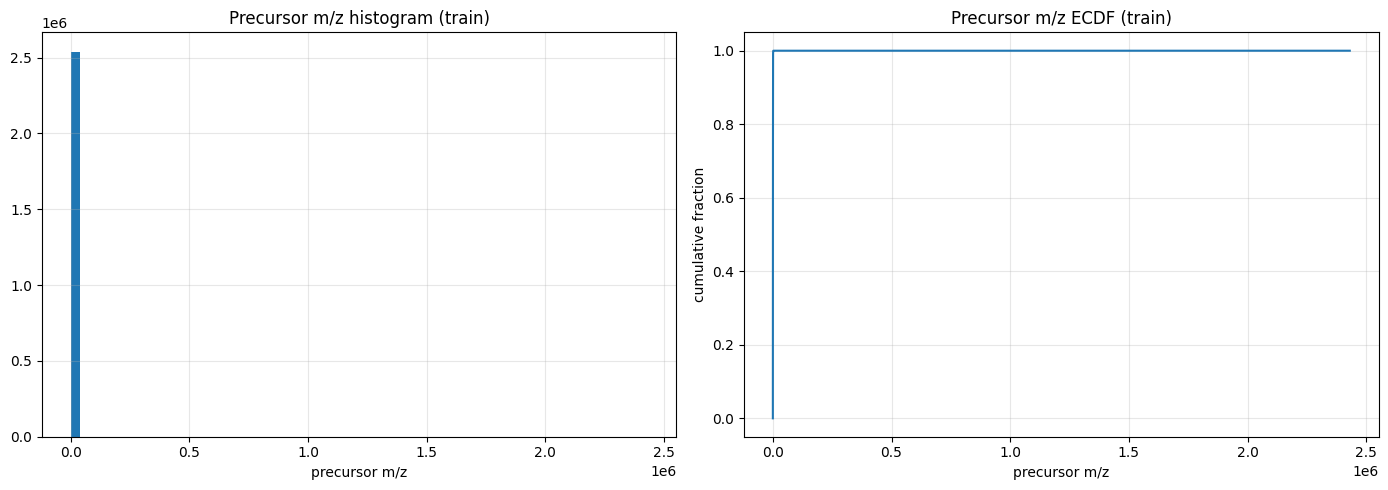

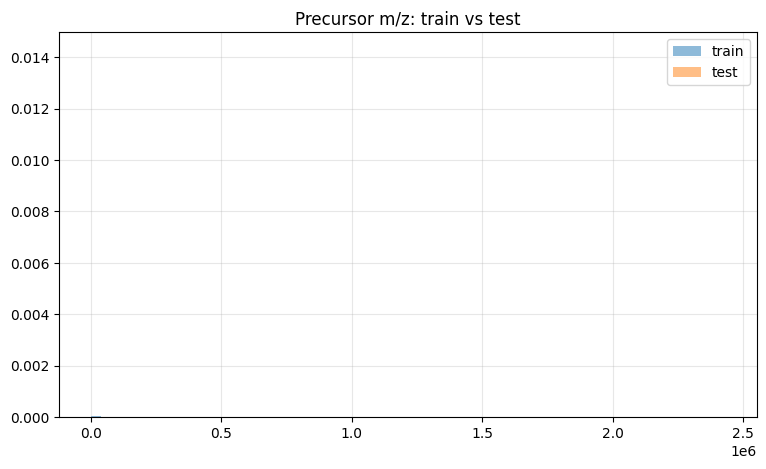

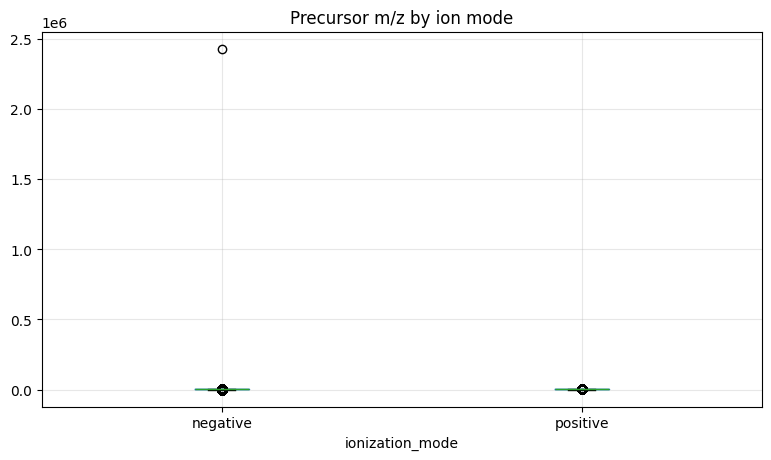

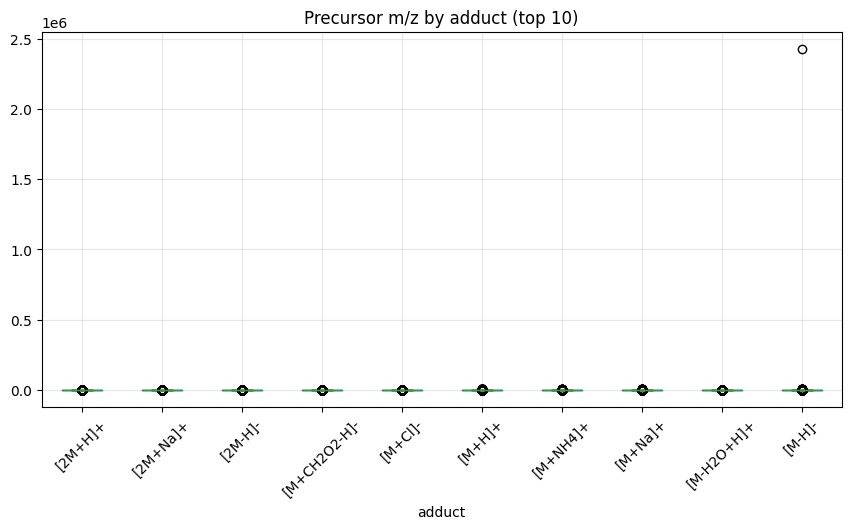

In [21]:

if mz_col and mz_col in train_df.columns:
    mz_series = train_df[mz_col].dropna()
    print(mz_series.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(mz_series, bins=60)
    axes[0].set_title("Precursor m/z histogram (train)")
    axes[0].set_xlabel("precursor m/z")

    sorted_mz = np.sort(mz_series.values)
    ecdf_y = np.arange(1, len(sorted_mz) + 1) / len(sorted_mz)
    axes[1].plot(sorted_mz, ecdf_y)
    axes[1].set_title("Precursor m/z ECDF (train)")
    axes[1].set_xlabel("precursor m/z")
    axes[1].set_ylabel("cumulative fraction")
    plt.tight_layout()
    plt.show()

    if mz_col in test_df.columns:
        fig, ax = plt.subplots()
        ax.hist(mz_series, bins=60, alpha=0.5, density=True, label="train")
        ax.hist(test_df[mz_col].dropna(), bins=60, alpha=0.5, density=True, label="test")
        ax.set_title("Precursor m/z: train vs test")
        ax.legend()
        plt.show()

    if ion_col and ion_col in train_df.columns:
        fig, ax = plt.subplots()
        train_df.boxplot(column=mz_col, by=ion_col, ax=ax)
        ax.set_title("Precursor m/z by ion mode")
        plt.suptitle("")
        plt.show()

    if adduct_col and adduct_col in train_df.columns:
        top_adducts = train_df[adduct_col].value_counts().head(10).index
        fig, ax = plt.subplots(figsize=(10, 5))
        train_df[train_df[adduct_col].isin(top_adducts)].boxplot(column=mz_col, by=adduct_col, ax=ax, rot=45)
        ax.set_title("Precursor m/z by adduct (top 10)")
        plt.suptitle("")
        plt.show()
else:
    print("precursor_mz_col not set -- fill in DATA_MAP (Section 3).")


In [22]:

# Common adduct mass offsets (Da), for sanity-checking precursor_mz - exact_mass
ADDUCT_OFFSETS = {
    "[M+H]+": 1.00728,
    "[M-H]-": -1.00728,
    "[M+Na]+": 22.98922,
    "[M+K]+": 38.96316,
    "[M+NH4]+": 18.03437,
    "[M+Cl]-": 34.96885,
    "[M+HCOO]-": 44.99820,
    "[M+CH3COO]-": 59.01385,
    "[M]+": 0.0,
    "[M]-": 0.0,
}

if mz_col and smiles_col and adduct_col and mol_col:
    merged = train_df[[mol_col, mz_col, adduct_col]].merge(
        struct_df[[mol_col, "exact_mass"]], on=mol_col, how="left"
    )
    merged["mz_minus_exact_mass"] = merged[mz_col] - merged["exact_mass"]

    offset_summary = merged.groupby(adduct_col)["mz_minus_exact_mass"].agg(["count", "mean", "std", "median"])
    offset_summary["expected_offset"] = offset_summary.index.map(ADDUCT_OFFSETS)
    offset_summary["diff_from_expected"] = offset_summary["mean"] - offset_summary["expected_offset"]
    display(offset_summary.sort_values("count", ascending=False))

    consistent = offset_summary.dropna(subset=["expected_offset"])
    if len(consistent):
        well_explained = (consistent["diff_from_expected"].abs() < 0.02).mean()
        print(f"\nOf adducts with a known theoretical offset, "
              f"{well_explained:.0%} have observed mean offset within 0.02 Da of theory.")
else:
    print("Skipping -- requires precursor_mz_col, smiles_col, adduct_col, molecule_id_col in DATA_MAP.")


,count,mean,std,median,expected_offset,diff_from_expected
adduct,,,,,,
[M+H]+,1386041,1.2861,15.1626,1.0075,1.0073,0.2788
[M-H]-,493469,4.2155,"3,459.3432",-1.0073,-1.0073,5.2227
[2M+Na]+,190364,355.1740,36.0353,355.1742,NaN,NaN
[M+Na]+,186042,23.8615,15.3355,22.9892,22.9892,0.8723
[2M+H]+,92547,343.2025,43.1145,341.1891,NaN,NaN
...,...,...,...,...,...,...
[3M+Na-H4O2]+,1,255.0839,NaN,255.0839,NaN,NaN
[M-C4H11O2]+,1,-91.0764,NaN,-91.0764,NaN,NaN
[M-C8H9O]+,1,-121.0654,NaN,-121.0654,NaN,NaN



Of adducts with a known theoretical offset, 0% have observed mean offset within 0.02 Da of theory.


**Observation:** measured `precursor_mz - exact_mass` per adduct, compared with the
textbook adduct offset.

**Why it matters:** if offsets are chemically consistent, precursor mass + adduct can be
used to reconstruct a tight neutral-mass window for candidate generation.

**Implication for modeling:** use this relationship in Notebook 02's mass-based candidate
filter (Section 20).


## 9. Ionization mode and adduct EDA

In [23]:

for col, label in [(ion_col, "ion mode"), (adduct_col, "adduct")]:
    if col and col in train_df.columns:
        print(f"--- {label} ({col}) value counts (train) ---")
        vc = train_df[col].value_counts(dropna=False)
        vc_pct = (vc / vc.sum() * 100).round(2)
        display(pd.DataFrame({"count": vc, "pct": vc_pct}))

if ion_col and adduct_col and ion_col in train_df.columns and adduct_col in train_df.columns:
    print("--- ion_mode x adduct cross-tab (train) ---")
    display(pd.crosstab(train_df[ion_col], train_df[adduct_col]))


--- ion mode (ionization_mode) value counts (train) ---


,count,pct
ionization_mode,,
positive,1899640,74.8000
negative,639968,25.2000


--- adduct (adduct) value counts (train) ---


,count,pct
adduct,,
[M+H]+,1324585,52.1600
[M-H]-,465688,18.3400
[2M+Na]+,190033,7.4800
[M+Na]+,178092,7.0100
[2M+H]+,92041,3.6200
...,...,...
[M-O]+,1,0.0000
[M-C7H5O]+,1,0.0000
[2M+Na-O2]+,1,0.0000


--- ion_mode x adduct cross-tab (train) ---


adduct,[2M+C2H4N]+,[2M+C2H4O2-H]-,[2M+CH2O2-H]-,[2M+Ca-H]+,[2M+Ca]2+,[2M+H-O2]+,[2M+H]+,[2M+K]+,[2M+NH4]+,[2M+Na-2H]-,[2M+Na-H2O]+,[2M+Na-H5N]-,[2M+Na-O2]+,[2M+Na-O3]+,[2M+Na2-H3]+,[2M+Na2-H]+,[2M+Na3-H4]-,[2M+Na]+,[2M-H3O2]+,[2M-H3]-,[2M-H5O3]+,[2M-HO]+,[2M-H]+,[2M-H]-,[3M+Ca-H]+,[3M+Ca]2+,[3M+H4N]+,[3M+K]+,[3M+Na-H4O2]+,[3M+Na]+,[3M-H]-,[4M+Ca]2+,[5M+Ca]2+,[Cat]2+,[M+2H]2+,[M+2Na-H]+,[M+3H]3+,[M+Br]-,[M+C2F3O2]-,[M+C2H2NaO2]-,[M+C2H3NNa]+,[M+C2H4N]+,[M+C2H4O2-H]-,[M+C2H5N]2+,[M+C2H7N2]+,[M+C2H7OS]+,[M+C2HO]-,[M+C4H8N2]+,[M+C6H11N3]+,[M+CH2O2-H]-,[M+CH3O2]+,[M+CH3]+,[M+CH5O]+,[M+Ca-H]+,[M+Ca]2+,[M+Cl]-,[M+H-CO2]+,[M+H-CO]+,[M+H-O3S]+,[M+H-O]+,[M+H3O]+,[M+H3]+,[M+HNa]2+,[M+HO]+,[M+HO]-,[M+H]+,[M+K-H2]-,[M+K]+,[M+Li-H]+,[M+Li]+,[M+N-O2]+,[M+NH4]+,[M+Na-H2O]+,[M+Na-H2]-,[M+Na-H]+,[M+Na2]2+,[M+Na3]3+,[M+Na]+,[M-2H2O+H]+,[M-2H]-,[M-C12H19O9]+,[M-C18H29O14]+,[M-C2H3O]-,[M-C3H5]+,[M-C3H6NO2]-,[M-C3H7O2]-,[M-C4H11O2]+,[M-C4H7]+,[M-C5H7O3]+,[M-C5H9N2O]+,[M-C6H11O5]-,[M-C6H11O6]+,[M-C6H13O2]+,[M-C6H9O4]+,[M-C6H9O5]+,[M-C6H9O8S]+,[M-C7H11O6]+,[M-C7H5O]+,[M-C8H9O]+,[M-C9H9O5]+,[M-CH3F2O2]-,[M-CH3O]+,[M-CH3]-,[M-CH4]-,[M-CO2-H]-,[M-H21]-,[M-H2N]+,[M-H2O+H]+,[M-H2O-H]-,[M-H2O2]2+,[M-H2O]+,[M-H2]2-,[M-H4O3]2+,[M-H5O3]+,[M-H7O4]+,[M-H9O5]+,[M-H]-,[M-O3P]+,[M-O]+,[M]+,[M]-
ionization_mode,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
negative,0,187,665,0,0,0,0,0,0,1431,0,1,0,0,0,0,1,0,0,1,0,0,0,56172,0,0,0,0,0,0,6,0,0,0,0,0,0,45,25,15,0,0,7436,0,0,0,1,0,0,83188,0,0,0,0,0,27493,0,0,0,0,3,0,0,0,1,675,32,0,0,0,0,10,0,29,0,0,0,18,0,454,0,0,2,0,72,4,0,0,0,0,8,0,0,0,0,0,0,0,0,0,11,0,619,1,7,1,0,70,280,0,0,102,0,0,0,0,460430,0,0,26,446
positive,2,0,0,5,33,2,92041,109,378,0,1,0,1,1,1,2,0,190033,14,0,1,19,4,0,2,9,2,1,1,15,0,10,4,15,1717,110,138,0,0,0,24,158,0,2,2,1,0,3,7,0,9,18,67,12,85,18,2,3,17,1,1,1,44,1,0,1323910,0,18955,4,6,3,53442,1,3,4,14,1,178074,3439,0,6,1,0,1,0,0,1,1,1,1,0,3,1,1,8,6,1,1,1,3,0,1,0,0,0,0,61,21612,5,1,624,1,2,230,7,3,5258,2,1,8792,0


In [24]:

for col, label in [(ion_col, "ion mode"), (adduct_col, "adduct")]:
    if col and col in train_df.columns and col in test_df.columns:
        train_set = set(train_df[col].dropna().unique())
        test_set = set(test_df[col].dropna().unique())
        only_train = train_set - test_set
        only_test = test_set - train_set
        print(f"{label}: categories only in TRAIN: {only_train if only_train else 'none'}")
        print(f"{label}: categories only in TEST:  {only_test if only_test else 'none'}")

        rare = train_df[col].value_counts()
        rare = rare[rare <= max(5, int(0.001 * len(train_df)))]
        print(f"{label}: rare train categories (<=~0.1% of rows): {list(rare.index)}\n")


ion mode: categories only in TRAIN: none
ion mode: categories only in TEST:  none
ion mode: rare train categories (<=~0.1% of rows): []

adduct: categories only in TRAIN: {'[M+C2H5N]2+', '[M+C2H3NNa]+', '[M-H4O3]2+', '[M-C6H9O8S]+', '[M+Ca]2+', '[M-C6H9O5]+', '[3M+H4N]+', '[2M-H3]-', '[M+C2H2NaO2]-', '[M+H3]+', '[M-C8H9O]+', '[M-C6H11O5]-', '[2M-H5O3]+', '[2M+Na-2H]-', '[M]+', '[M+C2H7OS]+', '[M-C4H11O2]+', '[M+C2H4N]+', '[M+H-CO]+', '[M+H-O]+', '[M-2H2O+H]+', '[M+Na3]3+', '[M-C4H7]+', '[M-H2O2]2+', '[M+CH3O2]+', '[M-H2]2-', '[M-CH3]-', '[4M+Ca]2+', '[M-O3P]+', '[M-O]+', '[M-C18H29O14]+', '[M-2H]-', '[2M+K]+', '[M-C7H11O6]+', '[M+K-H2]-', '[M+Li]+', '[2M+H-O2]+', '[M-H2O]+', '[M]-', '[M+3H]3+', '[3M+Na]+', '[3M+Ca-H]+', '[M+2H]2+', '[M-C5H9N2O]+', '[2M+C2H4O2-H]-', '[M-H2O+H]+', '[2M-H]+', '[2M+NH4]+', '[M-C6H11O6]+', '[2M-H]-', '[M+C6H11N3]+', '[M+HNa]2+', '[M-H21]-', '[M-H9O5]+', '[M+HO]+', '[M+CH3]+', '[M-CH3O]+', '[2M+Na3-H4]-', '[Cat]2+', '[M-C7H5O]+', '[3M-H]-', '[M+C2F3O2]-', '[

## 10. Collision energy analysis

In [25]:
# Collision-energy analysis was already normalized in Section 4.5.
# Here we focus on molecule-level experimental diversity without grouping raw list objects.

if len(train_ce_features):
    ce_analysis = pd.concat(
        [
            train_df[[c for c in [mol_col, ce_orig_col, ce_units_col, mz_col, adduct_col, ion_col, inst_col] if c in train_df.columns]]
            .reset_index(drop=True),
            train_ce_features.reset_index(drop=True),
        ],
        axis=1,
    )

    print("Collision-energy scalar summaries:")
    display(
        ce_analysis[
            ["ce_n_steps", "ce_min", "ce_mean", "ce_max", "ce_std", "ce_range"]
        ].describe(percentiles=[.05,.25,.5,.75,.95,.99])
    )

    if mol_col in ce_analysis.columns:
        # Deduplicate settings BEFORE grouping: exact and fast.
        ce_pairs = (
            ce_analysis[[mol_col, "ce_min", "ce_mean", "ce_max", "ce_n_steps"]]
            .drop_duplicates()
        )
        ce_per_mol = ce_pairs.groupby(mol_col, sort=False).size()

        print("\nDistinct normalized CE settings per molecule:")
        display(
            ce_per_mol.describe(percentiles=[.5,.75,.9,.95,.99]).to_frame("n_ce_settings")
        )

        multi_ce_mols = ce_per_mol[ce_per_mol > 1]
        print(
            f"Molecules with >1 normalized CE setting: "
            f"{len(multi_ce_mols):,}/{len(ce_per_mol):,} "
            f"({len(multi_ce_mols)/max(len(ce_per_mol),1)*100:.2f}%)"
        )

        if len(multi_ce_mols):
            example_mol = multi_ce_mols.index[0]
            print(f"\nExample multi-CE molecule: {example_mol}")
            display(
                ce_analysis.loc[
                    ce_analysis[mol_col] == example_mol,
                    [c for c in [
                        mol_col, "ce_n_steps", "ce_min", "ce_mean", "ce_max",
                        ce_orig_col, ce_units_col, mz_col, adduct_col, ion_col, inst_col
                    ] if c in ce_analysis.columns]
                ].drop_duplicates().head(30)
            )
else:
    print("No collision-energy derived features available.")


Collision-energy scalar summaries:


,ce_n_steps,ce_min,ce_mean,ce_max,ce_std,ce_range
count,"2,539,608.0000","2,202,165.0000","2,202,165.0000","2,202,165.0000","2,202,165.0000","2,202,165.0000"
mean,1.2890,32.7569,36.6937,40.9382,3.3419,8.1812
std,1.0008,20.4930,19.1268,20.8000,6.4592,15.7599
min,0.0000,0.0000,0.6000,0.6000,0.0000,0.0000
5%,0.0000,10.0000,10.0000,10.0000,0.0000,0.0000
25%,1.0000,20.0000,20.0000,20.0000,0.0000,0.0000
50%,1.0000,22.5000,40.0000,40.0000,0.0000,0.0000
75%,1.0000,40.0000,40.0000,60.0000,0.0000,0.0000
95%,3.0000,60.0000,60.0000,60.0000,16.3299,40.0000
99%,4.0000,93.7000,94.0000,99.3000,17.4918,41.5000



Distinct normalized CE settings per molecule:


,n_ce_settings
count,"275,810.0000"
mean,4.5847
std,4.2971
min,1.0000
50%,4.0000
75%,4.0000
90%,9.0000
95%,13.0000
99%,23.0000
max,76.0000


Molecules with >1 normalized CE setting: 234,932/275,810 (85.18%)

Example multi-CE molecule: AAKJLRGGTJKAMG


,inchikey14,ce_n_steps,ce_min,ce_mean,ce_max,collision_energy_orig,collision_energy_orig_units,precursor_mz,adduct,ionization_mode,instrument_type
1,AAKJLRGGTJKAMG,0,NaN,NaN,NaN,None,unknown,432.1320,[M+K]+,positive,None
1156510,AAKJLRGGTJKAMG,0,NaN,NaN,NaN,None,unknown,394.1760,[M+H]+,positive,Orbitrap
1156525,AAKJLRGGTJKAMG,0,NaN,NaN,NaN,None,unknown,394.1770,[M+H]+,positive,qTof
1156526,AAKJLRGGTJKAMG,0,NaN,NaN,NaN,None,unknown,394.1770,[M+H]+,positive,ToF
1156527,AAKJLRGGTJKAMG,0,NaN,NaN,NaN,None,unknown,394.1780,[M+H]+,positive,qTof
1156530,AAKJLRGGTJKAMG,0,NaN,NaN,NaN,None,unknown,395.1810,[M+H]+,positive,qTof
1156533,AAKJLRGGTJKAMG,0,NaN,NaN,NaN,None,unknown,416.1600,[M+H]+,positive,qTof
1156536,AAKJLRGGTJKAMG,0,NaN,NaN,NaN,None,unknown,809.3310,[M+H]+,positive,qTof
1156539,AAKJLRGGTJKAMG,0,NaN,NaN,NaN,None,unknown,392.1620,[M-H]-,negative,Orbitrap
1377988,AAKJLRGGTJKAMG,2,15.8000,35.5000,55.2000,Ramp 20%-70% (nominal),NCE,394.1751,[M+H]+,positive,LC-ESI-QFT


## 11. Spectrum-level EDA

Reusable `plot_spectrum` function used throughout the rest of the notebook.


In [26]:

def get_spectrum_peaks(row_or_id):
    """Return (mz, intensity) for a given train_df/test_df row: `peaks_col` and
    `peaks_intensity_col` are already parallel `list<double>` arrays (pyarrow decodes them
    straight into numpy arrays), so this is a direct lookup -- no string parsing needed.
    """
    if isinstance(row_or_id, pd.Series):
        row = row_or_id
        mz_field, int_field = DATA_MAP["peaks_col"], DATA_MAP["peaks_intensity_col"]
        if mz_field in row.index and row[mz_field] is not None:
            mz = np.asarray(row[mz_field], dtype=float)
            intensity = np.asarray(row[int_field], dtype=float) if (int_field in row.index and row[int_field] is not None) else np.array([])
            return mz, intensity
    return np.array([]), np.array([])


def plot_spectrum(mz, intensity, title=None, precursor_mz=None, collision_energy=None,
                   adduct=None, ion_mode=None, max_mz=None, normalize=True, ax=None):
    """Stem plot of a single spectrum: fragment m/z (x) vs relative intensity (y)."""
    mz = np.asarray(mz, dtype=float)
    intensity = np.asarray(intensity, dtype=float)
    if max_mz is not None:
        keep = mz <= max_mz
        mz, intensity = mz[keep], intensity[keep]
    if normalize and len(intensity) and intensity.max() > 0:
        intensity = intensity / intensity.max()

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(9, 4))

    if len(mz):
        ax.vlines(mz, 0, intensity, linewidth=1)
        ax.scatter(mz, intensity, s=8)
    else:
        ax.text(0.5, 0.5, "no peaks", ha="center", va="center", transform=ax.transAxes)

    if precursor_mz is not None:
        ax.axvline(precursor_mz, color="red", linestyle="--", linewidth=1, label=f"precursor {precursor_mz:.4f}")
        ax.legend(fontsize=8)

    subtitle_bits = []
    if adduct is not None:
        subtitle_bits.append(f"adduct={adduct}")
    if ion_mode is not None:
        subtitle_bits.append(f"mode={ion_mode}")
    if collision_energy is not None:
        subtitle_bits.append(f"CE={collision_energy}")
    subtitle = "  |  ".join(subtitle_bits)

    full_title = title or ""
    if subtitle:
        full_title = f"{full_title}\n{subtitle}" if full_title else subtitle
    ax.set_title(full_title, fontsize=10)
    ax.set_xlabel("fragment m/z")
    ax.set_ylabel("relative intensity" if normalize else "intensity")

    if own_fig:
        plt.tight_layout()
        plt.show()

print("plot_spectrum() ready.")


plot_spectrum() ready.


## 12. Peak statistics

compute_spectrum_features() ready.


,n_peaks,mz_min,mz_max,mz_mean,mz_std,intensity_max,intensity_mean,intensity_median,base_peak_mz,fraction_peaks_below_100,fraction_peaks_below_200,fraction_intensity_top1,fraction_intensity_top5,fragment_mass_range
count,"2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000","2,539,608.0000"
mean,158.2158,91.5766,380.1850,212.5840,75.6643,1.0000,0.1364,0.0759,233.6766,0.1849,0.5904,0.4680,0.7908,288.6084
std,516.8801,96.1410,209.4175,112.0596,53.1641,0.0000,0.1936,0.1902,144.3140,0.1919,0.3255,0.2399,0.1974,209.3308
min,1.0000,0.0008,19.8520,19.8520,0.0000,1.0000,0.0001,0.0000,9.0000,0.0000,0.0000,0.0002,0.0007,0.0000
25%,14.0000,42.0337,279.0913,142.2923,45.1573,1.0000,0.0187,0.0008,130.0414,0.0161,0.3333,0.2774,0.6796,179.0568
50%,42.0000,65.0379,335.1880,177.9883,67.0424,1.0000,0.0656,0.0077,191.0381,0.1429,0.6667,0.4308,0.8467,263.3265
75%,164.0000,95.0870,409.0447,253.3421,90.4537,1.0000,0.1636,0.0400,321.1978,0.2768,0.8667,0.6514,0.9518,331.5947
max,"73,318.0000","1,809.2110","4,971.1230","1,809.2110","1,641.5208",1.0000,1.0000,1.0000,"2,147.4840",1.0000,1.0000,1.0000,1.0000,"4,915.2600"


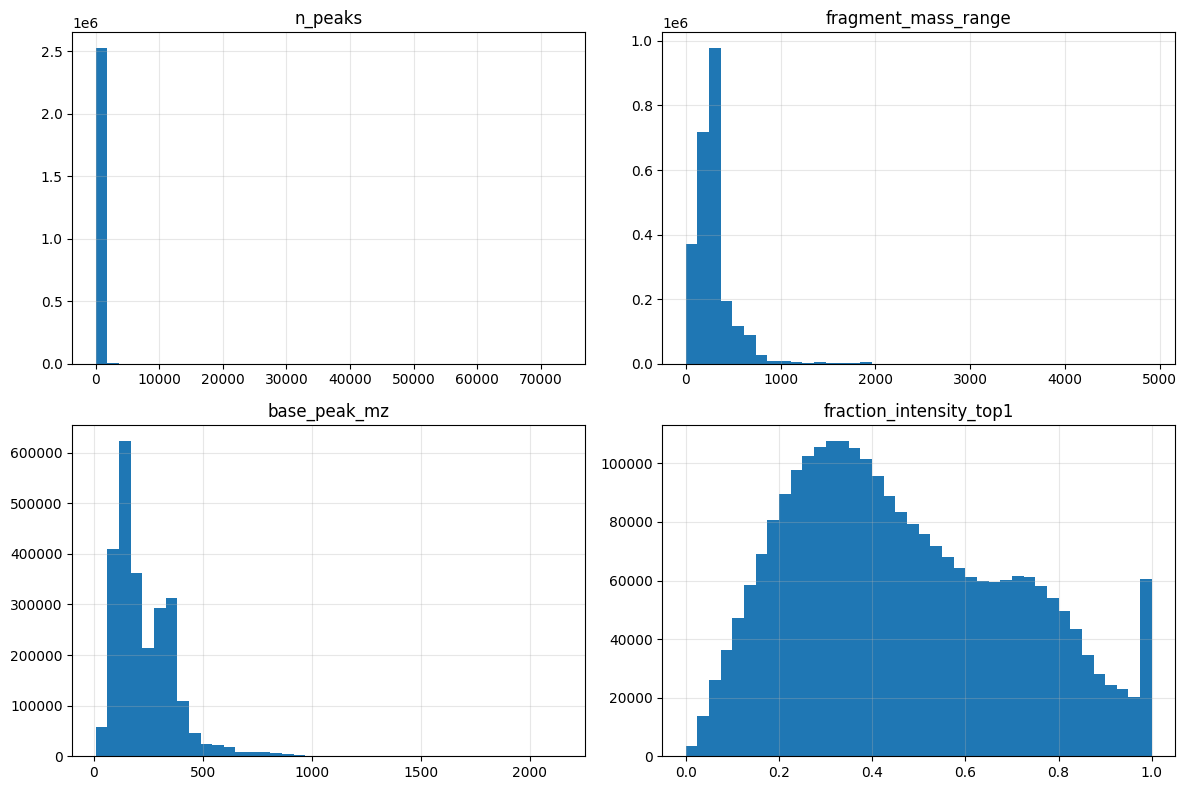

In [27]:

def compute_spectrum_features(mz, intensity, precursor_mz=None):
    mz = np.asarray(mz, dtype=float)
    intensity = np.asarray(intensity, dtype=float)
    n = len(mz)
    out = dict(n_peaks=n, mz_min=np.nan, mz_max=np.nan, mz_mean=np.nan, mz_std=np.nan,
               intensity_max=np.nan, intensity_mean=np.nan, intensity_median=np.nan,
               base_peak_mz=np.nan, fraction_peaks_below_100=np.nan,
               fraction_peaks_below_200=np.nan, fraction_intensity_top1=np.nan,
               fraction_intensity_top5=np.nan, fragment_mass_range=np.nan)
    if n == 0:
        return out
    out["mz_min"] = mz.min()
    out["mz_max"] = mz.max()
    out["mz_mean"] = mz.mean()
    out["mz_std"] = mz.std()
    out["intensity_max"] = intensity.max()
    out["intensity_mean"] = intensity.mean()
    out["intensity_median"] = np.median(intensity)
    out["base_peak_mz"] = mz[np.argmax(intensity)]
    out["fraction_peaks_below_100"] = np.mean(mz < 100)
    out["fraction_peaks_below_200"] = np.mean(mz < 200)
    total_int = intensity.sum()
    if total_int > 0:
        sorted_int = np.sort(intensity)[::-1]
        out["fraction_intensity_top1"] = sorted_int[:1].sum() / total_int
        out["fraction_intensity_top5"] = sorted_int[:5].sum() / total_int
    out["fragment_mass_range"] = mz.max() - mz.min()
    return out

print("compute_spectrum_features() ready.")

if DATA_MAP["peaks_col"] and DATA_MAP["peaks_col"] in train_df.columns:
    feats = []
    for _, row in train_df.iterrows():
        mz, inten = get_spectrum_peaks(row)
        feats.append(compute_spectrum_features(mz, inten, row.get(mz_col)))
    peak_feat_df = pd.DataFrame(feats)
    train_spectrum_features = pd.concat([train_df.reset_index(drop=True), peak_feat_df], axis=1)

    display(peak_feat_df.describe())

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0,0].hist(peak_feat_df["n_peaks"].dropna(), bins=40); axes[0,0].set_title("n_peaks")
    axes[0,1].hist(peak_feat_df["fragment_mass_range"].dropna(), bins=40); axes[0,1].set_title("fragment_mass_range")
    axes[1,0].hist(peak_feat_df["base_peak_mz"].dropna(), bins=40); axes[1,0].set_title("base_peak_mz")
    axes[1,1].hist(peak_feat_df["fraction_intensity_top1"].dropna(), bins=40); axes[1,1].set_title("fraction_intensity_top1")
    plt.tight_layout()
    plt.show()
else:
    train_spectrum_features = pd.DataFrame()
    print("peaks_col not set in DATA_MAP -- populate it (or adapt get_spectrum_peaks) before running this cell.")


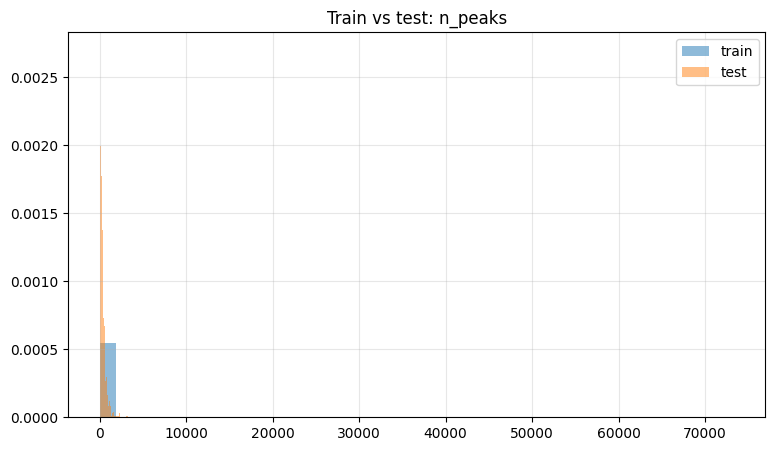

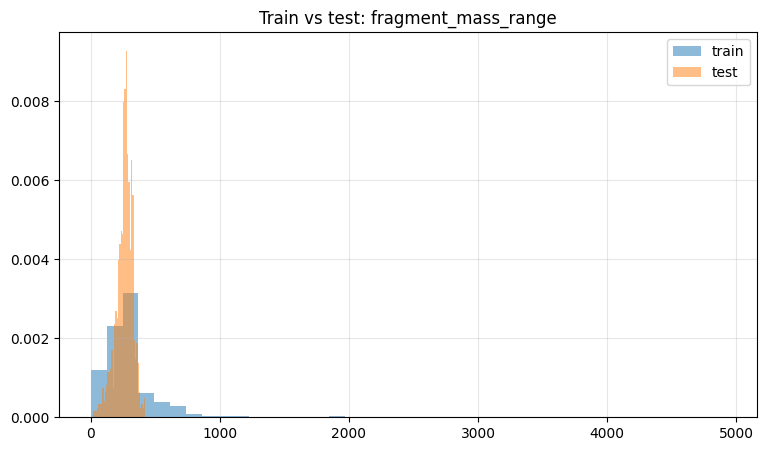

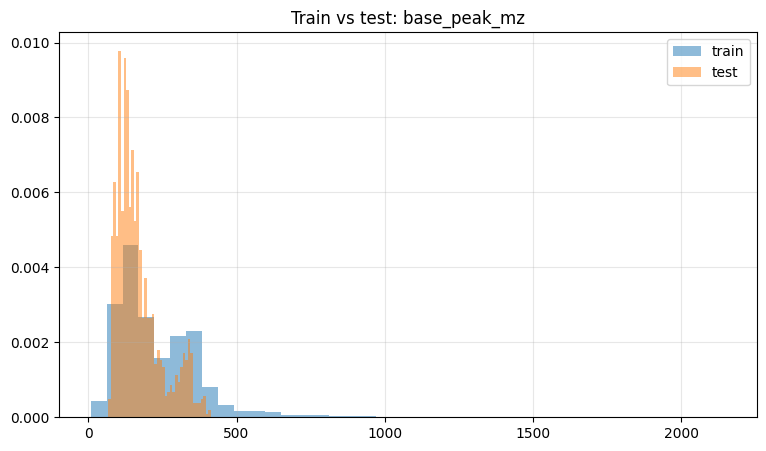

In [28]:

# Train vs test comparison of peak-derived features requires peaks to also be available
# for test (they normally are -- spectra are the *input*, SMILES are the *target*).
if len(train_spectrum_features) and DATA_MAP["peaks_col"] in test_df.columns:
    test_feats = []
    for _, row in test_df.iterrows():
        mz, inten = get_spectrum_peaks(row)
        test_feats.append(compute_spectrum_features(mz, inten, row.get(mz_col)))
    test_peak_feat_df = pd.DataFrame(test_feats)

    for col in ["n_peaks", "fragment_mass_range", "base_peak_mz"]:
        fig, ax = plt.subplots()
        ax.hist(peak_feat_df[col].dropna(), bins=40, alpha=0.5, density=True, label="train")
        ax.hist(test_peak_feat_df[col].dropna(), bins=40, alpha=0.5, density=True, label="test")
        ax.set_title(f"Train vs test: {col}")
        ax.legend()
        plt.show()


## 13. Spectrum examples

Eight representative spectra spanning low/high mass, few/many peaks, both ion modes,
and common/unusual adducts.


--- low precursor mass ---
inchikey14                                                                                                                                                                                                      ZWCXYZRRTRDGQE
normalized_smiles      CC(C)CC(NC(=O)C(C)NC(=O)CNC(=O)C(NC=O)C(C)C)C(=O)NC(C)C(=O)NC(C(=O)NC(C(=O)NC(C(=O)NC(Cc1c[nH]c2ccccc12)C(=O)NC(CC(C)C)C(=O)NC(Cc1c[nH]c2ccccc12)C(=O)NC(CC(C)C)C(=O)NC(Cc1c[nH]c2ccccc12)C(=O)NC(CC...
precursor_mz                                                                                                                                                                                                            2.0000
adduct                                                                                                                                                                                                                [M+2H]2+
ionization_mode                                                                  

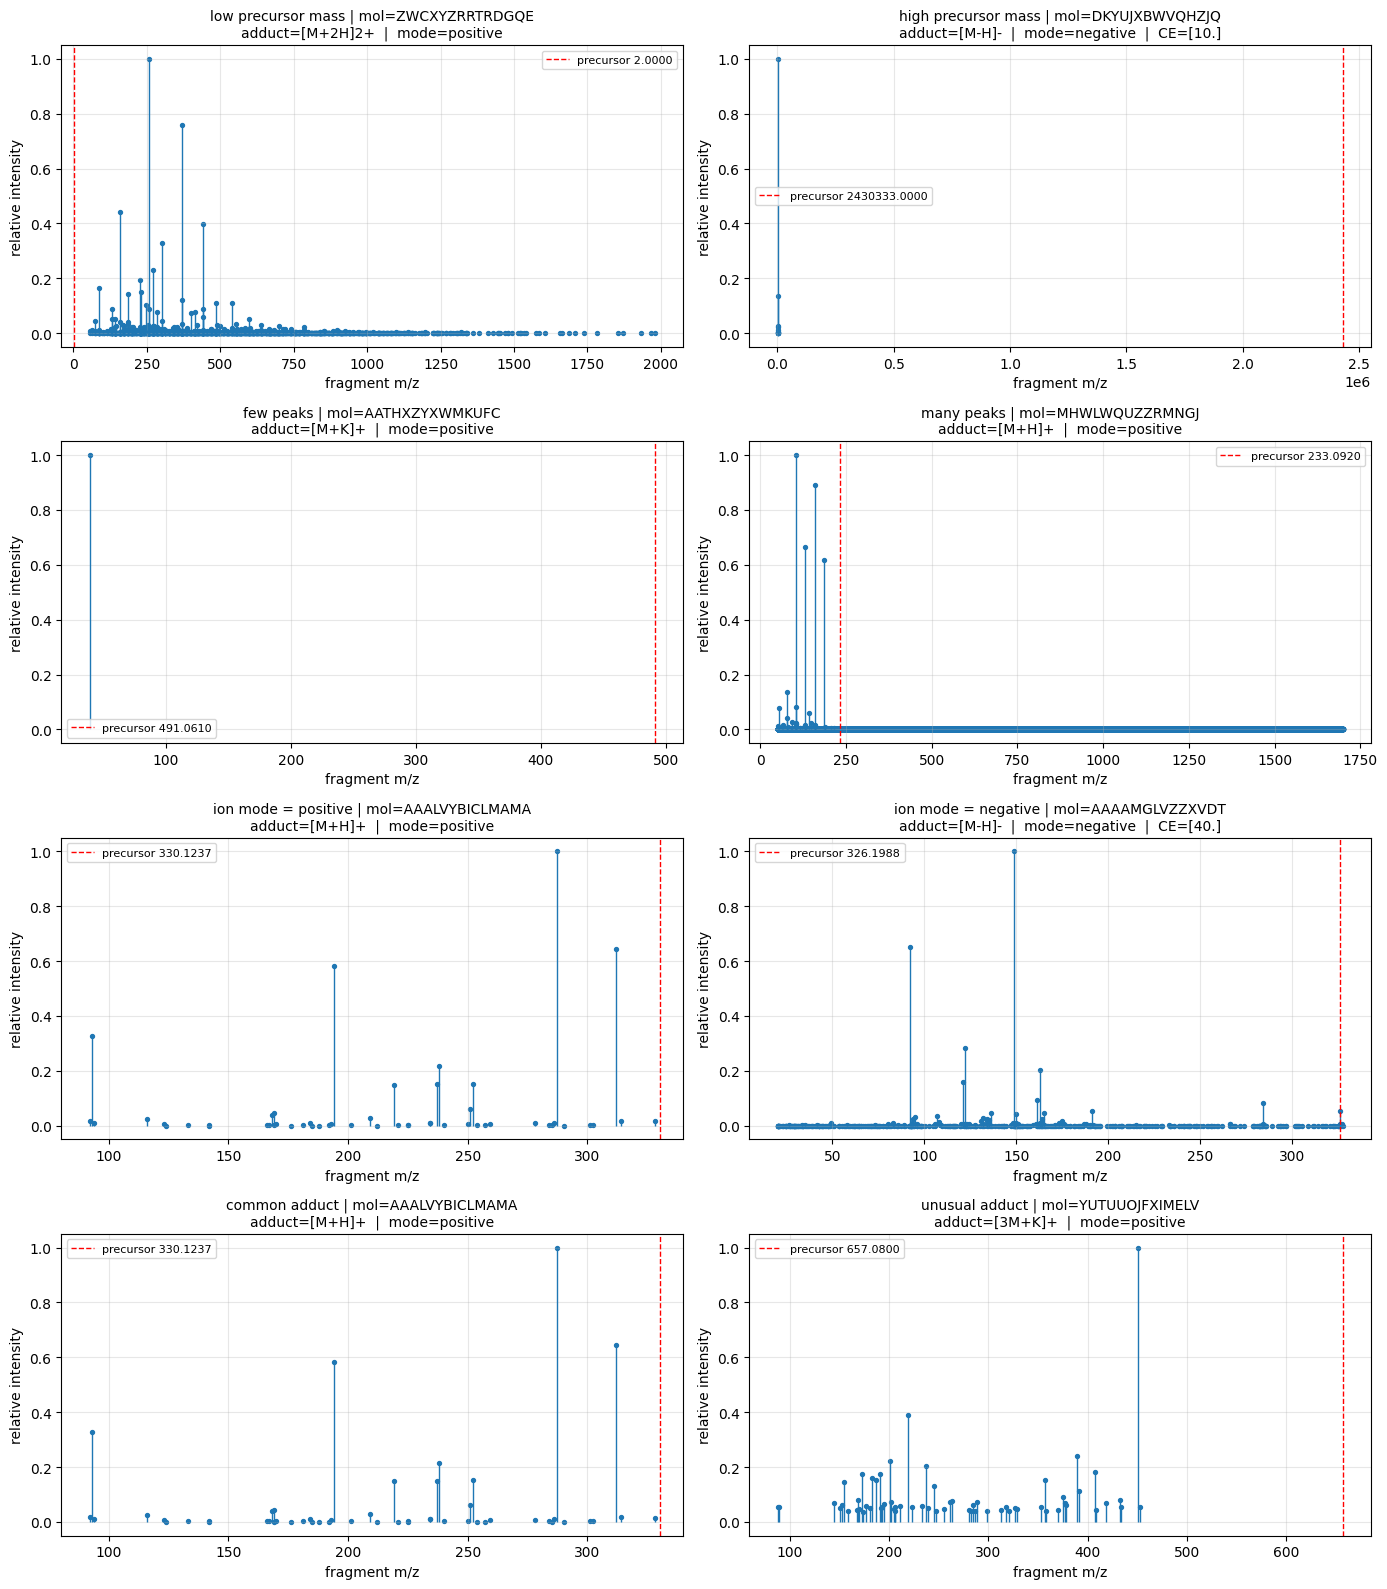

In [29]:

if len(train_spectrum_features):
    df_ex = train_spectrum_features.copy()
    picks = {}

    if mz_col in df_ex.columns:
        picks["low precursor mass"] = df_ex.loc[df_ex[mz_col].idxmin()]
        picks["high precursor mass"] = df_ex.loc[df_ex[mz_col].idxmax()]
    if "n_peaks" in df_ex.columns:
        nonzero = df_ex[df_ex["n_peaks"] > 0]
        if len(nonzero):
            picks["few peaks"] = nonzero.loc[nonzero["n_peaks"].idxmin()]
            picks["many peaks"] = nonzero.loc[nonzero["n_peaks"].idxmax()]
    if ion_col and ion_col in df_ex.columns:
        modes = df_ex[ion_col].dropna().unique()
        for m in modes[:2]:
            picks[f"ion mode = {m}"] = df_ex[df_ex[ion_col] == m].iloc[0]
    if adduct_col and adduct_col in df_ex.columns:
        vc = df_ex[adduct_col].value_counts()
        if len(vc):
            picks["common adduct"] = df_ex[df_ex[adduct_col] == vc.index[0]].iloc[0]
        if len(vc) > 1:
            picks["unusual adduct"] = df_ex[df_ex[adduct_col] == vc.index[-1]].iloc[0]

    n = len(picks)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (label, row) in zip(axes, picks.items()):
        mz, inten = get_spectrum_peaks(row)
        title_bits = [f"{label}"]
        if mol_col:
            title_bits.append(f"mol={row.get(mol_col)}")
        plot_spectrum(
            mz, inten, title=" | ".join(title_bits),
            precursor_mz=row.get(mz_col), collision_energy=row.get(ce_col),
            adduct=row.get(adduct_col), ion_mode=row.get(ion_col), ax=ax,
        )
        info_cols = [c for c in [mol_col, smiles_col, mz_col, adduct_col, ion_col, ce_col, "n_peaks"] if c and c in row.index]
        print(f"--- {label} ---")
        print(row[info_cols])
        print()

    for ax in axes[len(picks):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping -- requires train_spectrum_features from Section 12.")


## 14. Same molecule, different spectrum

How variable is the observed spectrum for exactly the same molecular structure across
different acquisition settings?


In [31]:
# ============================================================
# FIND REPEATED MOLECULES WITH VARYING EXPERIMENTAL CONDITIONS
# Handles numpy arrays / lists / dicts safely
# ============================================================

import numpy as np
import pandas as pd


def make_hashable(x):
    """
    Convert nested/non-hashable objects into stable hashable forms
    without modifying the original dataframe.
    """

    # Missing scalar
    if x is None:
        return None

    # numpy array
    if isinstance(x, np.ndarray):
        return tuple(
            make_hashable(v)
            for v in x.tolist()
        )

    # list / tuple
    if isinstance(x, (list, tuple)):
        return tuple(
            make_hashable(v)
            for v in x
        )

    # dict
    if isinstance(x, dict):
        return tuple(
            sorted(
                (
                    k,
                    make_hashable(v)
                )
                for k, v in x.items()
            )
        )

    # set
    if isinstance(x, set):
        return tuple(
            sorted(
                make_hashable(v)
                for v in x
            )
        )

    # numpy scalar
    if isinstance(x, np.generic):
        return x.item()

    # pandas missing value
    try:
        if pd.isna(x):
            return None
    except (TypeError, ValueError):
        pass

    return x


# ------------------------------------------------------------
# 1. Keep only varying columns that actually exist
# ------------------------------------------------------------

varying_cols_safe = [
    c
    for c in varying_cols
    if c in train_spectrum_features.columns
]

print("Columns checked for variation:")
print(varying_cols_safe)


# ------------------------------------------------------------
# 2. Diagnose which columns contain arrays / lists
# ------------------------------------------------------------

print("\nPotential non-scalar columns:")

for col in varying_cols_safe:

    sample = (
        train_spectrum_features[col]
        .dropna()
        .head(100)
    )

    non_scalar = sample.map(
        lambda x: isinstance(
            x,
            (
                np.ndarray,
                list,
                tuple,
                dict,
                set,
            )
        )
    ).any()

    if non_scalar:
        print(f"  {col}")


# ------------------------------------------------------------
# 3. Find molecules with genuinely varying conditions
# ------------------------------------------------------------

chosen = []

for m in repeated_mols:

    sub = train_spectrum_features.loc[
        train_spectrum_features[mol_col] == m,
        varying_cols_safe
    ].copy()

    if len(sub) <= 1:
        continue

    # Convert only columns needed for comparison
    for col in varying_cols_safe:
        if sub[col].dtype == "object":
            sub[col] = sub[col].map(
                make_hashable
            )

    # Now drop_duplicates works even with original ndarray columns
    n_unique_conditions = (
        sub
        .drop_duplicates()
        .shape[0]
    )

    if n_unique_conditions > 1:
        chosen.append(m)

    if len(chosen) >= 5:
        break


print(
    f"\nSelected {len(chosen)} repeated molecules "
    f"with varying experimental conditions:"
)

print(chosen)

Columns checked for variation:
['collision_energy_ev', 'adduct', 'ionization_mode']

Potential non-scalar columns:
  collision_energy_ev

Selected 5 repeated molecules with varying experimental conditions:
['PFTAWBLQPZVEMU', 'LPLVUJXQOOQHMX', 'AIONOLUJZLIMTK', 'RWXIFXNRCLMQCD', 'TZBJGXHYKVUXJN']


**Observation:** visual variability of repeated spectra for the same molecule under
different collision energy / adduct / ion mode.

**Why it matters:** if within-molecule spectral variability is high, a naive nearest-neighbor
retrieval baseline needs to be robust to acquisition condition, not just structure.

**Implication for modeling:** consider normalizing or conditioning spectral similarity on
collision energy / adduct in Notebook 02.


## 15. Similar molecules, different spectra (Morgan / Tanimoto)

In [32]:

def get_morgan_fp(smiles, radius=2, n_bits=2048):
    if not RDKIT_AVAILABLE or smiles is None:
        return None
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    try:
        from rdkit.Chem import rdFingerprintGenerator
        gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
        return gen.GetFingerprint(mol)
    except Exception:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

if len(struct_df):
    valid_struct = struct_df.dropna(subset=["canonical_smiles"]).drop_duplicates("connectivity_key").reset_index(drop=True)
    valid_struct["morgan_fp"] = valid_struct["canonical_smiles"].apply(get_morgan_fp)
    print(f"Computed Morgan fingerprints for {valid_struct['morgan_fp'].notna().sum()} structures.")
else:
    valid_struct = pd.DataFrame()
    print("Skipping -- requires struct_df.")


Computed Morgan fingerprints for 275810 structures.


In [33]:

if len(valid_struct) >= 2:
    fps = valid_struct["morgan_fp"].tolist()
    smis = valid_struct["canonical_smiles"].tolist()
    masses = valid_struct["exact_mass"].tolist()

    # Sample-limited all-pairs search to keep this tractable for large datasets
    MAX_MOLS_FOR_PAIR_SEARCH = 800
    rng = np.random.default_rng(SEED)
    if len(fps) > MAX_MOLS_FOR_PAIR_SEARCH:
        sample_idx = rng.choice(len(fps), MAX_MOLS_FOR_PAIR_SEARCH, replace=False)
    else:
        sample_idx = np.arange(len(fps))

    best_pairs = []
    for ii, i in enumerate(sample_idx):
        if fps[i] is None:
            continue
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], [fps[j] for j in sample_idx[ii+1:] if fps[j] is not None])
        js = [j for j in sample_idx[ii+1:] if fps[j] is not None]
        for sim, j in zip(sims, js):
            if 0.7 <= sim < 1.0:  # similar but not identical
                best_pairs.append((sim, i, j))

    best_pairs.sort(reverse=True)
    print(f"Found {len(best_pairs)} high-similarity (0.7-1.0) non-identical pairs in the sample.")

    for sim, i, j in best_pairs[:5]:
        print(f"\nTanimoto = {sim:.3f}")
        print(f"  SMILES A: {smis[i]}   exact_mass={masses[i]:.4f}")
        print(f"  SMILES B: {smis[j]}   exact_mass={masses[j]:.4f}")
else:
    print("Skipping -- need at least 2 valid structures with fingerprints.")


Found 34 high-similarity (0.7-1.0) non-identical pairs in the sample.

Tanimoto = 0.971
  SMILES A: CCCCCCCCC=CCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCC=CCCCCCCCC)OC(=O)CCCCCCCCCC=CCCCCCCCC   exact_mass=968.8772
  SMILES B: CCCCC=CCCCCCCCC(=O)OCC(COC(=O)CCCCCCCC=CCCCCCC)OC(=O)CCCCCCCC=CCCCC   exact_mass=744.6268

Tanimoto = 0.917
  SMILES A: CCCCCCCCC=CCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCC=CCCCCCCCC)OC(=O)CCCCCCCCCC=CCCCCCCCC   exact_mass=968.8772
  SMILES B: CCCCCC=CCC=CCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCC)OC(=O)CCCCCCCCCCCCC   exact_mass=760.6581

Tanimoto = 0.900
  SMILES A: CCCCCC=CCC=CCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCC)OC(=O)CCCCCCCCCCCCC   exact_mass=760.6581
  SMILES B: CCC=CCC=CCC=CCC=CCC=CCCCCCC(=O)OCC(COC(=O)CCCCCCCC=CCCCCCCCC)OC(=O)CCCC=CCC=CCC=CCC=CCCCCC   exact_mass=954.7676

Tanimoto = 0.892
  SMILES A: CCCCC=CCCCCCCCC(=O)OCC(COC(=O)CCCCCCCC=CCCCCCC)OC(=O)CCCCCCCC=CCCCC   exact_mass=744.6268
  SMILES B: CCCCCC=CCC=CCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCC)OC(=O)CCCCCCCCCCCCC   exact_m

## 16. Same or near-identical mass, different structure

This directly demonstrates why precursor mass alone cannot solve CASMI: many distinct
structures share (almost) the same exact mass.


In [34]:

if len(struct_df):
    valid = struct_df.dropna(subset=["exact_mass", "connectivity_key"]).drop_duplicates("connectivity_key")
    valid = valid.sort_values("exact_mass").reset_index(drop=True)

    MASS_TOL = 0.01
    near_mass_groups = []
    i = 0
    masses = valid["exact_mass"].values
    n = len(valid)
    while i < n:
        j = i
        while j + 1 < n and masses[j+1] - masses[i] < MASS_TOL:
            j += 1
        if j > i:
            near_mass_groups.append(valid.iloc[i:j+1])
        i = j + 1

    print(f"Found {len(near_mass_groups)} groups of structures within {MASS_TOL} Da of each other "
          f"(and with distinct connectivity).")

    for grp in near_mass_groups[:5]:
        print("\n" + "=" * 80)
        display(grp[["canonical_smiles", "molecular_formula", "exact_mass"]])
        if RDKIT_AVAILABLE and len(grp) >= 2:
            fp_a = get_morgan_fp(grp.iloc[0]["canonical_smiles"])
            fp_b = get_morgan_fp(grp.iloc[1]["canonical_smiles"])
            if fp_a is not None and fp_b is not None:
                sim = DataStructs.TanimotoSimilarity(fp_a, fp_b)
                print(f"Morgan similarity between first two entries: {sim:.3f}")
else:
    print("Skipping -- requires struct_df.")


Found 11950 groups of structures within 0.01 Da of each other (and with distinct connectivity).



,canonical_smiles,molecular_formula,exact_mass
5,CCN,C2H7N,45.0578
6,CNC,C2H7N,45.0578


Morgan similarity between first two entries: 0.111



,canonical_smiles,molecular_formula,exact_mass
8,CC(C)=O,C3H6O,58.0419
9,CCC=O,C3H6O,58.0419


Morgan similarity between first two entries: 0.154



...

Morgan similarity between first two entries: 0.143



,canonical_smiles,molecular_formula,exact_mass
18,CC(C)O,C3H8O,60.0575
19,CCCO,C3H8O,60.0575


Morgan similarity between first two entries: 0.167



,canonical_smiles,molecular_formula,exact_mass
23,c1cn[nH]c1,C3H4N2,68.0374
24,c1c[nH]cn1,C3H4N2,68.0374


Morgan similarity between first two entries: 0.238


**Observation:** groups of structurally distinct molecules within 0.01 Da of one
another, with (often) low Morgan similarity despite near-identical mass.

**Why it matters:** confirms precursor mass is necessary but not sufficient — it narrows
candidates but does not resolve structure on its own.

**Implication for modeling:** mass filtering should be paired with spectral similarity /
fragmentation-pattern reranking, not used alone.


## 17. Neutral-loss exploration

In [1]:

COMMON_LOSSES = {"H2O": 18.0106, "CO": 27.9949, "CO2": 43.9898, "NH3": 17.0265}

if len(train_spectrum_features) and mz_col in train_spectrum_features.columns:
    all_losses = []
    for _, row in train_spectrum_features.iterrows():
        prec = row.get(mz_col)
        if pd.isna(prec):
            continue
        mz, _ = get_spectrum_peaks(row)
        if len(mz):
            all_losses.extend((prec - mz).tolist())
    all_losses = np.array(all_losses)
    all_losses = all_losses[all_losses > 0]

    print(f"Computed {len(all_losses)} neutral-loss values from precursor - fragment m/z.")

    fig, ax = plt.subplots()
    ax.hist(all_losses, bins=200, range=(0, min(200, all_losses.max() if len(all_losses) else 200)))
    for name, val in COMMON_LOSSES.items():
        ax.axvline(val, color="red", linestyle="--", alpha=0.6)
        ax.text(val, ax.get_ylim()[1]*0.9, name, rotation=90, fontsize=8, color="red")
    ax.set_xlabel("neutral loss (Da)")
    ax.set_ylabel("count")
    ax.set_title("Neutral-loss distribution with common chemical losses marked")
    plt.show()

    TOL = 0.02
    for name, val in COMMON_LOSSES.items():
        frac = np.mean(np.abs(all_losses - val) < TOL) if len(all_losses) else np.nan
        print(f"  Fraction of neutral losses within {TOL} Da of {name} ({val}): {frac:.4%}")
else:
    print("Skipping -- requires train_spectrum_features with precursor_mz.")


NameError: name 'train_spectrum_features' is not defined

## 18. Peak-frequency analysis

In [ ]:

if len(train_spectrum_features) and mz_col in train_spectrum_features.columns:
    BIN_WIDTH = 0.01
    all_mz = []
    all_ratio = []
    for _, row in train_spectrum_features.iterrows():
        prec = row.get(mz_col)
        mz, _ = get_spectrum_peaks(row)
        if len(mz):
            all_mz.extend(mz.tolist())
            if pd.notna(prec) and prec > 0:
                all_ratio.extend((mz / prec).tolist())
    all_mz = np.array(all_mz)
    all_ratio = np.array(all_ratio)

    if len(all_mz):
        bins = np.arange(0, all_mz.max() + BIN_WIDTH, BIN_WIDTH)
        binned = pd.cut(all_mz, bins=bins)
        freq = pd.Series(binned).value_counts().sort_values(ascending=False)
        print("Most frequent fragment m/z bins across all training spectra:")
        display(freq.head(20))

    if len(all_ratio):
        fig, ax = plt.subplots()
        ax.hist(all_ratio, bins=100, range=(0, 1.05))
        ax.set_xlabel("fragment m/z / precursor m/z")
        ax.set_ylabel("count")
        ax.set_title("Normalized fragment m/z distribution")
        plt.show()
else:
    print("Skipping -- requires train_spectrum_features with precursor_mz.")


## 19. Spectrum similarity baseline analysis

Do spectra from the *same* molecule look more similar to each other than spectra from
*different* molecules? This tells us how promising a retrieval baseline is for Notebook 02.


In [ ]:

def bin_spectrum(mz, intensity, mz_max=1000, bin_width=1.0):
    n_bins = int(mz_max / bin_width) + 1
    vec = np.zeros(n_bins)
    if len(mz) == 0:
        return vec
    idx = np.clip((mz / bin_width).astype(int), 0, n_bins - 1)
    np.add.at(vec, idx, intensity)
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec

def compute_spectrum_similarity(mz1, int1, mz2, int2, mz_max=1000, bin_width=1.0):
    v1 = bin_spectrum(mz1, int1, mz_max, bin_width)
    v2 = bin_spectrum(mz2, int2, mz_max, bin_width)
    denom = (np.linalg.norm(v1) * np.linalg.norm(v2))
    if denom == 0:
        return 0.0
    return float(np.dot(v1, v2) / denom)

print("compute_spectrum_similarity() ready.")

if len(train_spectrum_features) and mol_col in train_spectrum_features.columns:
    binned_vecs = [
        bin_spectrum(*get_spectrum_peaks(row)) for _, row in train_spectrum_features.iterrows()
    ]
    mol_ids = train_spectrum_features[mol_col].values

    rng = np.random.default_rng(SEED)
    N_PAIRS = 3000

    same_sims, diff_sims = [], []
    n = len(binned_vecs)
    mol_to_indices = defaultdict(list)
    for i, m in enumerate(mol_ids):
        mol_to_indices[m].append(i)
    same_mol_candidates = [m for m, idxs in mol_to_indices.items() if len(idxs) >= 2]

    for _ in range(N_PAIRS):
        if same_mol_candidates and rng.random() < 0.5:
            m = same_mol_candidates[rng.integers(len(same_mol_candidates))]
            i, j = rng.choice(mol_to_indices[m], 2, replace=False)
            v1, v2 = binned_vecs[i], binned_vecs[j]
            denom = np.linalg.norm(v1) * np.linalg.norm(v2)
            same_sims.append(float(np.dot(v1, v2) / denom) if denom > 0 else 0.0)
        else:
            i, j = rng.choice(n, 2, replace=False)
            if mol_ids[i] == mol_ids[j]:
                continue
            v1, v2 = binned_vecs[i], binned_vecs[j]
            denom = np.linalg.norm(v1) * np.linalg.norm(v2)
            diff_sims.append(float(np.dot(v1, v2) / denom) if denom > 0 else 0.0)

    fig, ax = plt.subplots()
    ax.hist(same_sims, bins=40, alpha=0.6, density=True, label=f"same molecule (n={len(same_sims)})")
    ax.hist(diff_sims, bins=40, alpha=0.6, density=True, label=f"different molecule (n={len(diff_sims)})")
    ax.set_xlabel("binned cosine similarity")
    ax.set_title("Same-molecule vs different-molecule spectral similarity")
    ax.legend()
    plt.show()

    print(f"Mean same-molecule similarity: {np.mean(same_sims):.3f}" if same_sims else "No same-molecule pairs sampled.")
    print(f"Mean different-molecule similarity: {np.mean(diff_sims):.3f}" if diff_sims else "No different-molecule pairs sampled.")
else:
    print("Skipping -- requires train_spectrum_features and molecule_id_col.")


**Observation:** compare the two similarity distributions above.

**Why it matters:** if same-molecule similarity is clearly higher, nearest-neighbor
spectral retrieval is a credible baseline; if the distributions overlap heavily, retrieval
alone will be weak and structural priors (mass filtering, fragmentation rules) matter more.

**Implication for modeling:** this directly justifies (or tempers expectations for)
Notebook 02's retrieval-based approach.


## 20. Candidate-space analysis using precursor mass

In [ ]:

if len(struct_df) and "exact_mass" in struct_df.columns:
    valid = struct_df.dropna(subset=["exact_mass"]).drop_duplicates("connectivity_key").reset_index(drop=True)
    masses = np.sort(valid["exact_mass"].values)

    def count_within_ppm(masses_sorted, ppm):
        n = len(masses_sorted)
        counts = np.zeros(n, dtype=int)
        left = 0
        for i in range(n):
            tol = masses_sorted[i] * ppm / 1e6
            while masses_sorted[left] < masses_sorted[i] - tol:
                left += 1
            right = i
            while right + 1 < n and masses_sorted[right + 1] <= masses_sorted[i] + tol:
                right += 1
            counts[i] = right - left  # excluding self
        return counts

    rows = []
    for ppm in [5, 10, 20]:
        counts = count_within_ppm(masses, ppm)
        rows.append({
            "tolerance": f"±{ppm} ppm",
            "median_candidates": int(np.median(counts)),
            "p90_candidates": int(np.percentile(counts, 90)),
            "max_candidates": int(counts.max()),
        })
    candidate_space_table = pd.DataFrame(rows)
    display(candidate_space_table)
else:
    candidate_space_table = pd.DataFrame()
    print("Skipping -- requires struct_df with exact_mass.")


**Observation:** median/p90/max candidate counts at ±5/10/20 ppm mass tolerance, above.

**Why it matters:** small median candidate counts mean a `mass filter -> rerank` pipeline
is computationally practical; large tails (p90/max) mean some molecules will need a
stronger reranker to disambiguate many isobaric/isomeric candidates.

**Implication for modeling:** Notebook 02's candidate generator should use a mass window
in this range, informed by the adduct-offset analysis in Section 8.


## 21. Structural novelty / validation difficulty

In [ ]:

if mol_col and mol_col in train_df.columns and len(struct_df):
    conn_map_full = struct_df.set_index(mol_col)["connectivity_key"]
    scaffold_map_full = struct_df.set_index(mol_col)["scaffold_smiles"] if "scaffold_smiles" in struct_df.columns else None

    groups_connectivity = train_df[mol_col].map(conn_map_full)
    groups_scaffold = train_df[mol_col].map(scaffold_map_full) if scaffold_map_full is not None else None

    N_SPLITS = 5

    def summarize_split(name, tr_idx, va_idx, group_series):
        tr_groups = set(group_series.iloc[tr_idx].dropna())
        va_groups = set(group_series.iloc[va_idx].dropna())
        overlap = len(tr_groups & va_groups)
        row = {
            "split": name,
            "n_train": len(tr_idx),
            "n_val": len(va_idx),
            "n_train_groups": len(tr_groups),
            "n_val_groups": len(va_groups),
            "group_overlap": overlap,
        }
        if mz_col in train_df.columns:
            row["train_mz_mean"] = train_df[mz_col].iloc[tr_idx].mean()
            row["val_mz_mean"] = train_df[mz_col].iloc[va_idx].mean()
        if adduct_col in train_df.columns:
            row["val_adduct_only_in_val"] = len(
                set(train_df[adduct_col].iloc[va_idx].dropna())
                - set(train_df[adduct_col].iloc[tr_idx].dropna())
            )
        return row

    split_summaries = []

    # Split A: naive random
    rng = np.random.default_rng(SEED)
    idx = np.arange(len(train_df))
    rng.shuffle(idx)
    cut = int(0.2 * len(idx))
    va_idx, tr_idx = idx[:cut], idx[cut:]
    split_summaries.append(summarize_split("A: random spectrum split", tr_idx, va_idx, groups_connectivity))

    # Split B: GroupKFold by connectivity
    valid_group_mask = groups_connectivity.notna()
    if valid_group_mask.sum() > N_SPLITS:
        gkf = GroupKFold(n_splits=N_SPLITS)
        X_dummy = np.zeros(valid_group_mask.sum())
        tr_i, va_i = next(gkf.split(X_dummy, groups=groups_connectivity[valid_group_mask].values))
        orig_idx = np.where(valid_group_mask.values)[0]
        split_summaries.append(summarize_split(
            "B: GroupKFold by connectivity_key", orig_idx[tr_i], orig_idx[va_i], groups_connectivity
        ))

    # Split C: GroupKFold by scaffold
    if groups_scaffold is not None:
        valid_scaf_mask = groups_scaffold.notna()
        if valid_scaf_mask.sum() > N_SPLITS:
            gkf = GroupKFold(n_splits=N_SPLITS)
            X_dummy = np.zeros(valid_scaf_mask.sum())
            tr_i, va_i = next(gkf.split(X_dummy, groups=groups_scaffold[valid_scaf_mask].values))
            orig_idx = np.where(valid_scaf_mask.values)[0]
            split_summaries.append(summarize_split(
                "C: GroupKFold by scaffold", orig_idx[tr_i], orig_idx[va_i], groups_scaffold
            ))

    split_comparison = pd.DataFrame(split_summaries)
    display(split_comparison)

    print("\nKey check -- group_overlap should be 0 for splits B and C, and is typically > 0 for split A:")
    display(split_comparison[["split", "group_overlap"]])
else:
    split_comparison = pd.DataFrame()
    print("Skipping -- requires struct_df, molecule_id_col, and train_df.")


## 22. Recommended competition CV strategy

*(Filled in dynamically from the Section 21 results — re-run after the data-dependent
cells above execute on the real competition data.)*


In [ ]:

if len(split_comparison):
    a_overlap = split_comparison.loc[split_comparison["split"].str.startswith("A"), "group_overlap"]
    b_overlap = split_comparison.loc[split_comparison["split"].str.startswith("B"), "group_overlap"]
    c_overlap = split_comparison.loc[split_comparison["split"].str.startswith("C"), "group_overlap"]

    a_val = int(a_overlap.iloc[0]) if len(a_overlap) else None
    b_val = int(b_overlap.iloc[0]) if len(b_overlap) else None
    c_val = int(c_overlap.iloc[0]) if len(c_overlap) else None

    print("RECOMMENDATION (derived from the measured overlaps above):")
    print("-" * 70)
    if a_val and a_val > 0:
        print(f"- Split A (naive random) leaks {a_val} molecule groups into validation -> DO NOT TRUST.")
    print(f"- Split B (GroupKFold by connectivity_key) group_overlap = {b_val} -> "
          f"{'safe, use as PRIMARY CV.' if b_val == 0 else 'unexpected overlap, investigate grouping.'}")
    if c_val is not None:
        print(f"- Split C (GroupKFold by scaffold) group_overlap = {c_val} -> "
              f"{'safe, use as SECONDARY/HARD CV for novel-scaffold generalization.' if c_val == 0 else 'unexpected overlap, investigate.'}")
    print("""
Primary CV     : GroupKFold(n_splits=5) grouped by connectivity_key (InChIKey14 after
                 tautomer canonicalization). Every molecule/connectivity appears in
                 exactly one fold.
Secondary CV   : GroupKFold grouped by Murcko scaffold, used to stress-test
                 generalization to unseen chemotypes (harder, smaller effective
                 training set per fold).
DO NOT TRUST   : any random spectrum-level split -- Section 6C and Split A above show
                 it leaks molecule identity between train and validation and will
                 overstate MRR@25 relative to true held-out performance.
""")
else:
    print("Run Section 21 on real data first to auto-derive this recommendation.")


## 23. Estimate known-vs-novel difficulty

Using the connectivity-grouped fold from Section 21, measure each validation molecule's
maximum Tanimoto similarity to anything in that fold's training partition.


In [ ]:

if len(valid_struct) and len(split_comparison) and mol_col in train_df.columns:
    # Reuse the connectivity-grouped split from Section 21
    valid_group_mask = groups_connectivity.notna()
    gkf = GroupKFold(n_splits=5)
    X_dummy = np.zeros(valid_group_mask.sum())
    tr_i, va_i = next(gkf.split(X_dummy, groups=groups_connectivity[valid_group_mask].values))
    orig_idx = np.where(valid_group_mask.values)[0]
    tr_idx, va_idx = orig_idx[tr_i], orig_idx[va_i]

    tr_conn = set(groups_connectivity.iloc[tr_idx].dropna())
    va_conn = set(groups_connectivity.iloc[va_idx].dropna())

    fp_lookup = dict(zip(valid_struct["connectivity_key"], valid_struct["morgan_fp"]))
    train_fps = [fp_lookup[c] for c in tr_conn if c in fp_lookup and fp_lookup[c] is not None]

    max_sims = []
    va_conn_list = [c for c in va_conn if c in fp_lookup and fp_lookup[c] is not None]
    for c in va_conn_list:
        fp = fp_lookup[c]
        if fp is None or not train_fps:
            continue
        sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
        max_sims.append(max(sims) if sims else 0.0)

    max_sims = np.array(max_sims)
    if len(max_sims):
        fig, ax = plt.subplots()
        ax.hist(max_sims, bins=40)
        ax.set_xlabel("max Tanimoto similarity to any training structure")
        ax.set_ylabel("count of validation structures")
        ax.set_title("Validation structural novelty (connectivity-grouped fold)")
        plt.show()

        bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
        labels = ["<0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
        bucketed = pd.cut(max_sims, bins=bins, labels=labels, include_lowest=True)
        bucket_counts = bucketed.value_counts().sort_index()
        bucket_pct = (bucket_counts / bucket_counts.sum() * 100).round(1)
        display(pd.DataFrame({"count": bucket_counts, "pct": bucket_pct}))
    else:
        print("Not enough fingerprints to compute max-Tanimoto-to-train.")
else:
    print("Skipping -- requires valid_struct (Section 15) and split_comparison (Section 21).")


**Observation:** distribution of validation molecules' maximum similarity to any
training molecule, bucketed exploratorily (bins are not scientifically load-bearing).

**Why it matters:** a large low-similarity mass means the grouped fold genuinely tests
generalization to novel chemistry, matching the real test set's likely composition.

**Implication for modeling:** report future model performance broken out by these buckets,
not just a single aggregate MRR@25.


## 24. Train/test distribution shift

In [ ]:

shift_rows = []

def ks_shift(train_vals, test_vals):
    train_vals = pd.Series(train_vals).dropna()
    test_vals = pd.Series(test_vals).dropna()
    if len(train_vals) < 5 or len(test_vals) < 5:
        return np.nan
    stat, _ = sp_stats.ks_2samp(train_vals, test_vals)
    return stat

def concern_level(stat):
    if pd.isna(stat):
        return "n/a"
    if stat < 0.05:
        return "small"
    if stat < 0.15:
        return "moderate"
    return "large"

for col, label in [(mz_col, "precursor_mz"), (ce_col, "collision_energy")]:
    if col and col in train_df.columns and col in test_df.columns and train_df[col].dtype.kind in "if":
        stat = ks_shift(train_df[col], test_df[col])
        shift_rows.append({"variable": label, "ks_statistic": round(stat, 4) if pd.notna(stat) else np.nan,
                            "concern_level": concern_level(stat),
                            "comment": "KS distance between train/test empirical distributions"})

for col, label in [(adduct_col, "adduct"), (ion_col, "ion_mode")]:
    if col and col in train_df.columns and col in test_df.columns:
        tr_p = train_df[col].value_counts(normalize=True)
        te_p = test_df[col].value_counts(normalize=True)
        all_cats = tr_p.index.union(te_p.index)
        tr_p = tr_p.reindex(all_cats, fill_value=0)
        te_p = te_p.reindex(all_cats, fill_value=0)
        tvd = 0.5 * (tr_p - te_p).abs().sum()  # total variation distance
        shift_rows.append({"variable": label, "ks_statistic": round(tvd, 4),
                            "concern_level": concern_level(tvd),
                            "comment": "total variation distance between category proportions"})

if 'peak_feat_df' in dir() and len(peak_feat_df) and 'test_peak_feat_df' in dir():
    for col in ["n_peaks", "fragment_mass_range"]:
        stat = ks_shift(peak_feat_df[col], test_peak_feat_df[col])
        shift_rows.append({"variable": col, "ks_statistic": round(stat, 4) if pd.notna(stat) else np.nan,
                            "concern_level": concern_level(stat), "comment": "KS distance, spectral feature"})

shift_table = pd.DataFrame(shift_rows)
shift_table


## 25. Missing values and data quality audit

We only **flag** suspicious records here — nothing is silently dropped.


In [ ]:

quality_flags = {}

if mz_col in train_df.columns:
    quality_flags["missing_precursor_mz"] = train_df[mz_col].isna().sum()
if DATA_MAP["peaks_col"] in train_df.columns:
    empty_peaks = train_df.apply(lambda r: len(get_spectrum_peaks(r)[0]) == 0, axis=1)
    quality_flags["empty_peak_lists"] = int(empty_peaks.sum())

    n_low_peak = train_df.apply(lambda r: 0 < len(get_spectrum_peaks(r)[0]) <= 2, axis=1).sum()
    quality_flags["spectra_with_1_or_2_peaks"] = int(n_low_peak)

    def has_zero_or_negative_intensity(row):
        _, inten = get_spectrum_peaks(row)
        return len(inten) > 0 and (inten <= 0).any()
    quality_flags["spectra_with_zero_or_negative_intensity"] = int(train_df.apply(has_zero_or_negative_intensity, axis=1).sum())

    def has_unsorted_mz(row):
        mz, _ = get_spectrum_peaks(row)
        return len(mz) > 1 and not np.all(np.diff(mz) >= 0)
    quality_flags["spectra_with_unsorted_mz"] = int(train_df.apply(has_unsorted_mz, axis=1).sum())

    def has_duplicate_peaks(row):
        mz, _ = get_spectrum_peaks(row)
        return len(mz) != len(set(np.round(mz, 4)))
    quality_flags["spectra_with_duplicate_peaks"] = int(train_df.apply(has_duplicate_peaks, axis=1).sum())

    if mz_col in train_df.columns:
        def frag_above_precursor(row):
            mz, _ = get_spectrum_peaks(row)
            prec = row.get(mz_col)
            return len(mz) > 0 and pd.notna(prec) and (mz > prec + 0.5).any()
        quality_flags["spectra_with_fragment_above_precursor"] = int(train_df.apply(frag_above_precursor, axis=1).sum())

if len(struct_df):
    quality_flags["invalid_smiles"] = int(struct_df["canonical_smiles"].isna().sum())

if mol_col in train_df.columns:
    quality_flags["duplicated_ids"] = int(train_df[mol_col].duplicated().sum())
    if spec_col and spec_col in train_df.columns:
        quality_flags["duplicated_spectrum_ids"] = int(train_df[spec_col].duplicated().sum())

if adduct_col in train_df.columns:
    known_adducts = set(ADDUCT_OFFSETS.keys())
    quality_flags["adduct_values_not_in_known_list"] = int((~train_df[adduct_col].isin(known_adducts)).sum())

quality_report = pd.Series(quality_flags, name="flagged_count").to_frame()
quality_report["flagged_pct_of_rows"] = (quality_report["flagged_count"] / max(len(train_df), 1) * 100).round(2)
quality_report


## Final visual recap

The most important figures are produced next to the corresponding analysis rather than repeated here:

1. spectra per molecular connectivity;
2. train/test distributions of every scalar observable variable;
3. category frequencies for every acquisition variable;
4. collision-energy step/ramp distributions;
5. raw spectrum-array integrity and fragment-range distributions;
6. precursor m/z and adduct relationships;
7. representative spectra;
8. same molecule measured under different acquisition settings;
9. scaffold-family distribution;
10. near-identical precursor/exact mass but different structures;
11. same-molecule vs different-molecule spectral similarity;
12. neutral-loss and high-frequency-fragment distributions;
13. mass-window candidate-space size;
14. structural novelty under leakage-safe validation;
15. train/test shift.


## Final EDA synthesis


In [ ]:

def _fmt(x, nd=3):
    try:
        return f"{x:,.{nd}f}"
    except Exception:
        return str(x)

summary_lines = []
summary_lines.append("### Dataset structure")
summary_lines.append(
    f"- OBSERVATION UNIT = spectrum, GROUPING UNIT = molecule/connectivity, TARGET = SMILES.\n"
    f"- Train rows: {len(train_df)}, unique molecules: {safe_nunique(train_df, mol_col)}, "
    f"unique connectivity keys: {struct_df['connectivity_key'].nunique() if len(struct_df) else 'n/a'}."
)

summary_lines.append("\n### Spectral characteristics")
if 'peak_feat_df' in dir() and len(peak_feat_df):
    summary_lines.append(
        f"- Median peaks/spectrum: {_fmt(peak_feat_df['n_peaks'].median(), 1)}, "
        f"median fragment mass range: {_fmt(peak_feat_df['fragment_mass_range'].median())}."
    )

summary_lines.append("\n### Chemical structure diversity")
if len(struct_df):
    summary_lines.append(
        f"- {struct_df['connectivity_key'].nunique()} unique structures across "
        f"{struct_df['scaffold_smiles'].nunique() if 'scaffold_smiles' in struct_df.columns else 'n/a'} scaffolds."
    )

summary_lines.append("\n### Leakage risk")
if len(split_comparison):
    a_row = split_comparison[split_comparison['split'].str.startswith('A')]
    if len(a_row):
        summary_lines.append(
            f"- Naive random spectrum split showed group_overlap = {int(a_row['group_overlap'].iloc[0])} "
            "-> random CV is NOT trustworthy for this dataset."
        )

summary_lines.append("\n### Train/test shift")
if len(shift_table):
    concerning = shift_table[shift_table['concern_level'] == 'large']
    if len(concerning):
        summary_lines.append(f"- Large shift flagged for: {', '.join(concerning['variable'])}.")
    else:
        summary_lines.append("- No variable showed a 'large' shift by the KS/TVD heuristics used.")

summary_lines.append("\n### Candidate-generation opportunity")
if len(candidate_space_table):
    summary_lines.append(
        f"- At ±10 ppm, median candidate count = "
        f"{candidate_space_table.set_index('tolerance').loc['±10 ppm', 'median_candidates'] if '±10 ppm' in candidate_space_table['tolerance'].values else 'n/a'}."
    )

summary_lines.append("\n### Retrieval opportunity")
if 'same_sims' in dir() and same_sims and diff_sims:
    summary_lines.append(
        f"- Mean same-molecule similarity ({np.mean(same_sims):.3f}) vs "
        f"different-molecule similarity ({np.mean(diff_sims):.3f})."
    )

summary_lines.append("\n### Novel-structure challenge")
if 'max_sims' in dir() and len(max_sims):
    frac_novel = np.mean(max_sims < 0.4)
    summary_lines.append(f"- {frac_novel:.1%} of connectivity-grouped validation structures have "
                          "max Tanimoto < 0.4 to any training structure.")

summary_lines.append("\n### Validation recommendation")
summary_lines.append(
    "- PRIMARY: GroupKFold by connectivity_key (InChIKey14, tautomer-canonicalized).\n"
    "- SECONDARY / HARD: GroupKFold by Murcko scaffold.\n"
    "- DO NOT TRUST: naive random spectrum-level splits."
)

print("\n".join(summary_lines))


## Reusable outputs

Persist only the chemistry/spectrum artifacts required by the next modeling notebook.  
The destination is local to the project: `outputs/eda_spectral/`.


In [ ]:
OUT_DIR = PROJECT_ROOT / "outputs" / "eda_spectral"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Structure-level metadata
if len(struct_df):
    n_spectra_per_mol = (
        train_df.groupby(mol_col).size().rename("n_spectra")
        if mol_col in train_df.columns else None
    )

    structure_metadata = struct_df.drop_duplicates("connectivity_key").copy()

    if n_spectra_per_mol is not None and mol_col in structure_metadata.columns:
        structure_metadata = structure_metadata.merge(
            n_spectra_per_mol,
            on=mol_col,
            how="left"
        )

    keep_cols = [
        c for c in [
            mol_col,
            "canonical_smiles",
            "connectivity_key",
            "scaffold_smiles",
            "exact_mass",
            "molecular_formula",
            "molecular_weight",
            "num_atoms",
            "num_heavy_atoms",
            "num_rings",
            "num_aromatic_rings",
            "num_heteroatoms",
            "num_rotatable_bonds",
            "formal_charge",
            "n_spectra",
        ]
        if c in structure_metadata.columns
    ]

    structure_metadata_out = structure_metadata[keep_cols]
    structure_metadata_out.to_parquet(
        OUT_DIR / "structure_metadata.parquet",
        index=False
    )
    print("Saved structure_metadata.parquet:", structure_metadata_out.shape)

# Spectrum-level metadata / features
if "train_spectrum_features" in globals() and len(train_spectrum_features):
    spectrum_metadata_out = train_spectrum_features.copy()

    # Add normalized CE summaries computed in the raw-variable section.
    if len(train_ce_features) == len(spectrum_metadata_out):
        for c in train_ce_features.columns:
            spectrum_metadata_out[c] = train_ce_features[c].values

    spectrum_metadata_out.to_parquet(
        OUT_DIR / "spectrum_metadata.parquet",
        index=False
    )
    print("Saved spectrum_metadata.parquet:", spectrum_metadata_out.shape)

# Compact diagnostic tables
raw_inventory.to_csv(OUT_DIR / "raw_variable_inventory.csv", index=False)

if "shift_table" in globals():
    shift_table.to_csv(OUT_DIR / "train_test_shift.csv", index=False)

if "quality_report" in globals():
    quality_report.to_csv(OUT_DIR / "quality_report.csv")

if "candidate_space_table" in globals():
    candidate_space_table.to_csv(OUT_DIR / "candidate_space_table.csv", index=False)

if "split_comparison" in globals():
    split_comparison.to_csv(OUT_DIR / "validation_split_comparison.csv", index=False)

print("\nEDA artifacts written to:", OUT_DIR.resolve())


## Modeling handoff

The next notebook should start from the scientific conclusions above rather than repeat data discovery:

```text
MS/MS preprocessing
→ precursor/adduct-aware candidate filtering
→ spectral representation
→ spectral similarity / retrieval
→ candidate ranking
→ MRR@25
```

Validation should be **grouped by molecular connectivity** as the primary estimate, with a scaffold-grouped split as a harder structural-novelty stress test.
